# Comparação de Algoritmos de Regressão para Predição de VALOR_VENDA
## Análise Completa com DecisionTree, RandomForest, KNeighbors, GradientBoosting e XGBoost

Este notebook apresenta uma análise comparativa de 5 algoritmos de regressão para prever o valor de venda de imóveis no Distrito Federal, através de Licitações Públicas da Empresa TERRACAP, avaliando seu desempenho através das métricas R², RMSE, MAE e MAPE em treino e teste.

## 0. Importação de Bibliotecas Necessárias

In [96]:
# Imports para análise de dados e visualização
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Imports para os modelos de regressão
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor


# Imports para pré-processamento
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Imports para validação cruzada
from sklearn.model_selection import KFold
from sklearn.base import clone

# Imports para explicabilidade
import re
import shap


# Imports para métricas de avaliação
from sklearn.metrics import (
    mean_absolute_error, 
    r2_score, 
    mean_absolute_percentage_error,
    root_mean_squared_error, 
    mean_squared_error
)

# Configurações de visualização
plt.style.use('default')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

## 1. Carregamento e Exploração dos Dados

In [71]:
# Carregar a base de dados
df = pd.read_csv('dados_vendas2022-2026.csv', sep=';', encoding='utf-8')

print(f"\nDimensões do dataset: {df.shape}")
print(f"Total de registros: {len(df)}")
print(f"Total de colunas: {df.shape[1]}\n")

print("Primeiras 5 linhas do dataset:")
print(df.head())

print("\n\nInformações das colunas:")
print(df.info())

print("\n\nEstatísticas Descritivas (Colunas Numéricas):")
print(df.describe())

print("\n\nValores Faltantes:")
print(df.isnull().sum())

print("\n\nTipo de dados das colunas:")
print(df.dtypes)


Dimensões do dataset: (1948, 21)
Total de registros: 1948
Total de colunas: 21

Primeiras 5 linhas do dataset:
    DS_CIDADE                                           DS_SETOR  \
0  TAGUATINGA                             BAIRRO AGUAS CLARAS-QS   
1    BRASILIA      SETOR DE HABITACOES INDIVIDUAIS NORTE           
2   CEILANDIA      SETOR O NORTE                                   
3   CEILANDIA  SETOR HABITACIONAL SOL NASCENTE TRECHO 01 ETAPA I   
4   CEILANDIA  SETOR HABITACIONAL SOL NASCENTE TRECHO 01 ETAPA I   

   COD_DESTINACAO_IMOVEL  ANO_VENDA NR_EDITAL  ITEM_EDITAL  VALOR_LAUDO  \
0                  60228       2022    2022-1            1     13800000   
1                  60211       2022    2022-1            2      1090000   
2                  60217       2022    2022-1            5      1730000   
3                  60219       2022    2022-1            7        48300   
4                  60219       2022    2022-1            8        48400   

   PERCENTUAL_ENTRADA  VALOR

## 2. Definição e análise da variável alvo


VALOR_VENDA - Estatísticas:
  Mínimo: R$ 23,000.01
  Máximo: R$ 41,451,000.00
  Média: R$ 815,405.20
  Mediana: R$ 337,638.89
  Desvio Padrão: R$ 2,266,013.92
  Valores nulos: 0


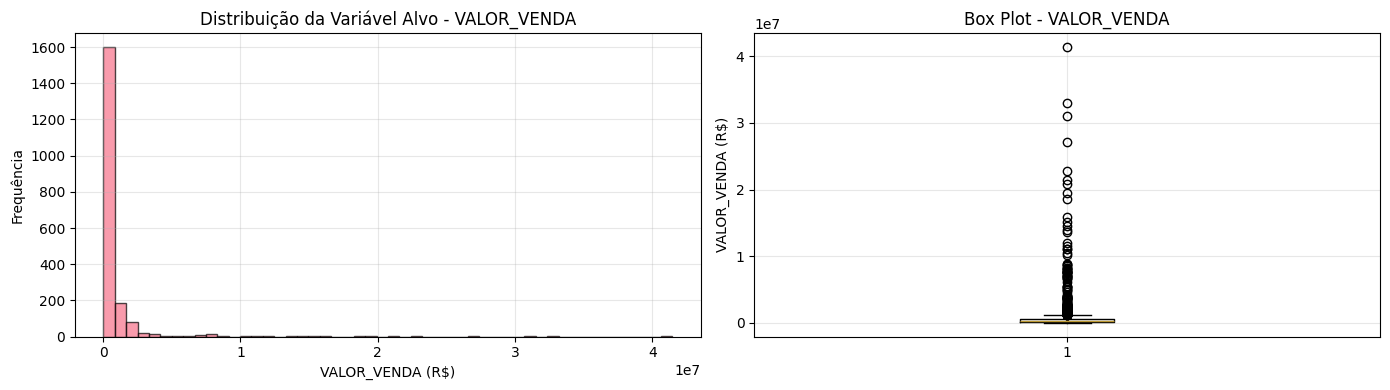

In [72]:
# Análise da variável alvo (VALOR_VENDA)

print(f"\nVALOR_VENDA - Estatísticas:")
print(f"  Mínimo: R$ {df['VALOR_VENDA'].min():,.2f}")
print(f"  Máximo: R$ {df['VALOR_VENDA'].max():,.2f}")
print(f"  Média: R$ {df['VALOR_VENDA'].mean():,.2f}")
print(f"  Mediana: R$ {df['VALOR_VENDA'].median():,.2f}")
print(f"  Desvio Padrão: R$ {df['VALOR_VENDA'].std():,.2f}")
print(f"  Valores nulos: {df['VALOR_VENDA'].isnull().sum()}")

# Visualização da distribuição
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histograma
axes[0].hist(df['VALOR_VENDA'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('VALOR_VENDA (R$)')
axes[0].set_ylabel('Frequência')
axes[0].set_title('Distribuição da Variável Alvo - VALOR_VENDA')
axes[0].grid(True, alpha=0.3)

# Box plot
axes[1].boxplot(df['VALOR_VENDA'])
axes[1].set_ylabel('VALOR_VENDA (R$)')
axes[1].set_title('Box Plot - VALOR_VENDA')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 3. Seleção de Features e Preparação dos Dados

In [73]:
# Separar variável alvo
y = df['VALOR_VENDA'].copy()

# Remover colunas que não são úteis para o modelo
# Removemos: DS_CIDADE (alta cardinalidade, mesma informação que DS_SETOR)
# Removemos: VALOR_LAUDO (correlacionada com VALOR_VENDA, seria usar o alvo)
# Removemos: AGIO_ABSOLUTO e AGIO_PERCENTUAL (derivadas do alvo)
# Removemos: QTD_OFERTAS (informação futura, não disponível no momento da predição)
# Removemos: ANO_VENDA, NR_EDITAL, ITEM_EDITAL, COD_DESTINACAO_IMOVEL (identificadores)
# Removemos: TIPO_USO_DESTINACAO, AREA_MAX_CONSTR, AREA_BASE (informações redundantes)

colunas_remover = [
    'DS_CIDADE', 'VALOR_VENDA', 'AREA_MAX_CONSTR', 'TIPO_USO_DESTINACAO', 
    'COD_DESTINACAO_IMOVEL', 'AGIO_ABSOLUTO', 'AGIO_PERCENTUAL', 'VALOR_LAUDO', 
    'AREA_BASE', 'QTD_OFERTAS', 'ANO_VENDA', 'ITEM_EDITAL', 'NR_EDITAL'
]

X = df.drop(columns=colunas_remover)

# Limpar colunas categóricas (remover espaços extras, caracteres não visíveis) para melhorar a consistência dos dados
for col in ["DS_SETOR", "SITUACAO_VISTORIA"]:
    if col in X.columns:
        X[col] = (X[col].astype(str)
                        .str.replace("\xa0", " ", regex=False)
                        .str.replace(r"\s+", " ", regex=True)
                        .str.strip())

print(f"\nColunas utilizadas como features (X):")
print(f"  Total: {X.shape[1]} variáveis")
print(f"Variáveis: {X.columns.tolist()}\n")

# Separar colunas numéricas e categóricas
colunas_numericas = ["AREA", "PERCENTUAL_ENTRADA", "RESIDENCIAL", "COMERCIAL", "INDUSTRIAL", "INSTITUCIONAL"]
colunas_categoricas = ["DS_SETOR", "SITUACAO_VISTORIA"]

print(f"Variáveis Numéricas ({len(colunas_numericas)}):")
for col in colunas_numericas:
    print(f"  - {col}")

print(f"\nVariáveis Categóricas ({len(colunas_categoricas)}):")
for col in colunas_categoricas:
    unique_vals = X[col].nunique()
    print(f"  - {col} ({unique_vals} categorias únicas)")

# Verificar valores faltantes
print(f"\nValores faltantes em X:")
print(X.isnull().sum())

print(f"\nForma de X: {X.shape}")
print(f"Forma de y: {y.shape}")


Colunas utilizadas como features (X):
  Total: 8 variáveis
Variáveis: ['DS_SETOR', 'PERCENTUAL_ENTRADA', 'AREA', 'SITUACAO_VISTORIA', 'RESIDENCIAL', 'COMERCIAL', 'INDUSTRIAL', 'INSTITUCIONAL']

Variáveis Numéricas (6):
  - AREA
  - PERCENTUAL_ENTRADA
  - RESIDENCIAL
  - COMERCIAL
  - INDUSTRIAL
  - INSTITUCIONAL

Variáveis Categóricas (2):
  - DS_SETOR (84 categorias únicas)
  - SITUACAO_VISTORIA (7 categorias únicas)

Valores faltantes em X:
DS_SETOR              0
PERCENTUAL_ENTRADA    0
AREA                  0
SITUACAO_VISTORIA     0
RESIDENCIAL           0
COMERCIAL             0
INDUSTRIAL            0
INSTITUCIONAL         0
dtype: int64

Forma de X: (1948, 8)
Forma de y: (1948,)


## 4. Divisão Treino-Teste

In [74]:
# Divisão dos dados em treino (80%) e teste (20%)
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTamanho do conjunto de treino: {X_treino.shape[0]} amostras ({X_treino.shape[1]} features)")
print(f"Tamanho do conjunto de teste: {X_teste.shape[0]} amostras ({X_teste.shape[1]} features)")
print(f"\nProporcionalidade:")
print(f"  Treino: {len(X_treino) / len(X) * 100:.1f}%")
print(f"  Teste: {len(X_teste) / len(X) * 100:.1f}%")

print(f"\nEstatísticas de y_treino:")
print(f"  Média: R$ {y_treino.mean():,.2f}")
print(f"  Mediana: R$ {y_treino.median():,.2f}")
print(f"  Min: R$ {y_treino.min():,.2f}")
print(f"  Max: R$ {y_treino.max():,.2f}")

print(f"\nEstatísticas de y_teste:")
print(f"  Média: R$ {y_teste.mean():,.2f}")
print(f"  Mediana: R$ {y_teste.median():,.2f}")
print(f"  Min: R$ {y_teste.min():,.2f}")
print(f"  Max: R$ {y_teste.max():,.2f}")


Tamanho do conjunto de treino: 1558 amostras (8 features)
Tamanho do conjunto de teste: 390 amostras (8 features)

Proporcionalidade:
  Treino: 80.0%
  Teste: 20.0%

Estatísticas de y_treino:
  Média: R$ 832,808.95
  Mediana: R$ 335,375.00
  Min: R$ 23,000.01
  Max: R$ 41,451,000.00

Estatísticas de y_teste:
  Média: R$ 745,879.44
  Mediana: R$ 352,550.00
  Min: R$ 25,000.00
  Max: R$ 33,000,000.00


## 5. Construção do Pipeline de Preprocessamento

In [75]:
# Pipeline para variáveis numéricas
pipeline_numericas = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline para variáveis categóricas
pipeline_categoricas = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# ColumnTransformer para combinar os pipelines
preprocessador = ColumnTransformer([
    ('numericas', pipeline_numericas, colunas_numericas),
    ('categoricas', pipeline_categoricas, colunas_categoricas)
])

print(f"\nPipeline para variáveis numéricas:")
print(f"  1. SimpleImputer (estratégia: mediana)")
print(f"  2. StandardScaler")

print(f"\nPipeline para variáveis categóricas:")
print(f"  1. SimpleImputer (estratégia: valor mais frequente)")
print(f"  2. OneHotEncoder")

# Aplicar preprocessamento
print("\nAplicando preprocessamento...")
X_treino_processado = preprocessador.fit_transform(X_treino)
X_teste_processado = preprocessador.transform(X_teste)

print(f"\nForma de X_treino após preprocessamento: {X_treino_processado.shape}")
print(f"Forma de X_teste após preprocessamento: {X_teste_processado.shape}")

# Obter nomes das features após OneHotEncoding
feature_names_numericas = colunas_numericas
feature_names_categoricas = preprocessador.named_transformers_['categoricas']['encoder'].get_feature_names_out(colunas_categoricas)
feature_names = list(feature_names_numericas) + list(feature_names_categoricas)

print(f"\nTotal de features após preprocessamento: {len(feature_names)}")


Pipeline para variáveis numéricas:
  1. SimpleImputer (estratégia: mediana)
  2. StandardScaler

Pipeline para variáveis categóricas:
  1. SimpleImputer (estratégia: valor mais frequente)
  2. OneHotEncoder

Aplicando preprocessamento...

Forma de X_treino após preprocessamento: (1558, 93)
Forma de X_teste após preprocessamento: (390, 93)

Total de features após preprocessamento: 93


## 6. Funções Auxiliares para Avaliação e Comparação

In [76]:
# Função para calcular todas as métricas
def calcular_metricas(y_real, y_predito):

    r2 = r2_score(y_real, y_predito)
    rmse = root_mean_squared_error(y_real, y_predito)
    mae = mean_absolute_error(y_real, y_predito)
    mape = mean_absolute_percentage_error(y_real, y_predito)
    
    return {
        'R2': r2,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE': mape
    }

# Função para exibir métricas visualmente formatadas
def exibir_metricas(nome_modelo, metricas_treino, metricas_teste):

    print(f"\n{nome_modelo}")
    print("-" * 70)
    print(f"{'Métrica':<15} {'Treino':<20} {'Teste':<20}")
    print("-" * 70)
    print(f"{'R²':<15} {metricas_treino['R2']:<20.6f} {metricas_teste['R2']:<20.6f}")
    print(f"{'RMSE':<15} {metricas_treino['RMSE']:<20.2f} {metricas_teste['RMSE']:<20.2f}")
    print(f"{'MAE':<15} {metricas_treino['MAE']:<20.2f} {metricas_teste['MAE']:<20.2f}")
    print(f"{'MAPE (%)':<15} {metricas_treino['MAPE']:<20.6f} {metricas_teste['MAPE']:<20.6f}")
    
    # Calcular diferença entre treino e teste para cada métrica
    diff_r2 = metricas_treino['R2'] - metricas_teste['R2']
    diff_rmse = metricas_teste['RMSE'] - metricas_treino['RMSE']
    diff_mae = metricas_teste['MAE'] - metricas_treino['MAE']
    diff_mape = metricas_teste['MAPE'] - metricas_treino['MAPE']
    print("-" * 70)
    print(f"Diferença R² (Treino - Teste): {diff_r2:.6f}")
    print(f"Diferença RMSE (Teste - Treino): {diff_rmse:.2f}")
    print(f"Diferença MAE (Teste - Treino): {diff_mae:.2f}")
    print(f"Diferença MAPE (Teste - Treino): {diff_mape:.6f}")


# Dicionário para armazenar resultados
resultados_modelos = {}

## 7. Modelo 1: Decision Tree Regressor

In [77]:
print("TREINAMENTO: DECISION TREE REGRESSOR")

# Definir modelo base
modelo_dt = DecisionTreeRegressor(random_state=42)

pipeline_dt = Pipeline([
    ("preprocessador", preprocessador),
    ("model", modelo_dt)
])


# Grid de hiperparâmetros ampla para busca abrangente, para encontrar a melhor combinação de hiperparâmetros para o modelo.
param_grid_dt = {
    'model__max_depth': [2, 3, 5, 7, 10, 15, 20],
    'model__min_samples_split': [2, 5, 10, 15, 20, 25],
    'model__min_samples_leaf': [1, 2, 4, 8]
}

# Para execução mais rápida durante o desenvolvimento, pode-se usar um grid ja com a combinação de hiperparâmetros mais promissora:
# Melhores hiperparâmetros encontrados:   {'model__max_depth': 5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 10}

# param_grid_dt = {
#     'model__max_depth': [5],
#     'model__min_samples_split': [10],
#     'model__min_samples_leaf': [1]
# }

# GridSearchCV
print("\nExecutando GridSearchCV...")
grid_search_dt = GridSearchCV(
    estimator=pipeline_dt,
    param_grid=param_grid_dt,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

# Dados brutos, sem preprocessamento, pois o pipeline já inclui o preprocessador
grid_search_dt.fit(X_treino, y_treino)

print(f"\nMelhores hiperparâmetros encontrados:")
print(f"  {grid_search_dt.best_params_}")
print(f"  Melhor score (CV RMSE): {grid_search_dt.best_score_:.6f}")

# Usar o melhor modelo
melhor_dt = grid_search_dt.best_estimator_

# Predições
y_treino_pred_dt = melhor_dt.predict(X_treino)
y_teste_pred_dt = melhor_dt.predict(X_teste)

# Calcular métricas
metricas_treino_dt = calcular_metricas(y_treino, y_treino_pred_dt)
metricas_teste_dt = calcular_metricas(y_teste, y_teste_pred_dt)

# Exibir métricas
exibir_metricas("DECISION TREE REGRESSOR", metricas_treino_dt, metricas_teste_dt)

# Armazenar resultados
resultados_modelos['Decision Tree'] = {
    'model': melhor_dt,
    'metricas_treino': metricas_treino_dt,
    'metricas_teste': metricas_teste_dt,
    'y_pred_teste': y_teste_pred_dt
}

TREINAMENTO: DECISION TREE REGRESSOR

Executando GridSearchCV...
Fitting 5 folds for each of 168 candidates, totalling 840 fits

Melhores hiperparâmetros encontrados:
  {'model__max_depth': 5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 10}
  Melhor score (CV RMSE): -1347053.273074

DECISION TREE REGRESSOR
----------------------------------------------------------------------
Métrica         Treino               Teste               
----------------------------------------------------------------------
R²              0.910329             0.849346            
RMSE            696419.98            778373.04           
MAE             258939.70            280205.22           
MAPE (%)        0.468442             0.470452            
----------------------------------------------------------------------
Diferença R² (Treino - Teste): 0.060983
Diferença RMSE (Teste - Treino): 81953.05
Diferença MAE (Teste - Treino): 21265.52
Diferença MAPE (Teste - Treino): 0.002010


## 8. Modelo 2: Random Forest Regressor

In [ ]:
print("TREINAMENTO: RANDOM FOREST REGRESSOR")

# Definir modelo base
modelo_rf = RandomForestRegressor(random_state=42, n_jobs=-1)

pipeline_rf = Pipeline([
    ("preprocessador", preprocessador),
    ("model", modelo_rf)
])

# Grid de hiperparâmetros ampla para busca abrangente, para encontrar a melhor combinação de hiperparâmetros para o modelo.
param_grid_rf = {
    "model__n_estimators": [300, 600, 1000],       
    "model__max_depth": [None, 10, 20, 30],        
    "model__min_samples_split": [2, 5, 10, 20],    
    "model__min_samples_leaf": [1, 2, 5, 10],      
    "model__max_features": ["sqrt", 0.5, 0.7, 1.0] 
}

# Para execução mais rápida durante o desenvolvimento, pode-se usar um grid ja com a combinação de hiperparâmetros mais promissora:
# Melhores hiperparâmetros encontrados:   {'model__max_depth': 30, 'model__max_features': 0.7, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 300}
# param_grid_rf = {
#     "model__n_estimators": [300],       
#     "model__max_depth": [20],        
#     "model__min_samples_split": [5],    
#     "model__min_samples_leaf": [1],      
#     "model__max_features": [1.0] 
# }

# GridSearchCV
print("\nExecutando GridSearchCV...")
grid_search_rf = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=param_grid_rf,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

# Dados brutos, sem preprocessamento, pois o pipeline já inclui o preprocessador
grid_search_rf.fit(X_treino, y_treino)

print(f"\nMelhores hiperparâmetros encontrados:")
print(f"  {grid_search_rf.best_params_}")
print(f"  Melhor score (CV RMSE): {grid_search_rf.best_score_:.6f}")

# Usar o melhor modelo
melhor_rf = grid_search_rf.best_estimator_

# Predições
y_treino_pred_rf = melhor_rf.predict(X_treino)
y_teste_pred_rf = melhor_rf.predict(X_teste)

# Calcular métricas
metricas_treino_rf = calcular_metricas(y_treino, y_treino_pred_rf)
metricas_teste_rf = calcular_metricas(y_teste, y_teste_pred_rf)

# Exibir métricas
exibir_metricas("RANDOM FOREST REGRESSOR", metricas_treino_rf, metricas_teste_rf)

# Armazenar resultados
resultados_modelos['Random Forest'] = {
    'model': melhor_rf,
    'metricas_treino': metricas_treino_rf,
    'metricas_teste': metricas_teste_rf,
    'y_pred_teste': y_teste_pred_rf
}

TREINAMENTO: RANDOM FOREST REGRESSOR

Executando GridSearchCV...
Fitting 5 folds for each of 768 candidates, totalling 3840 fits



Melhores hiperparâmetros encontrados:
  {'model__max_depth': 20, 'model__max_features': 1.0, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 300}
  Melhor score (CV RMSE): -1213088.265570

RANDOM FOREST REGRESSOR
----------------------------------------------------------------------
Métrica         Treino               Teste               
----------------------------------------------------------------------
R²              0.931857             0.864321            
RMSE            607093.67            738676.30           
MAE             145943.56            191948.77           
MAPE (%)        0.168883             0.222884            
----------------------------------------------------------------------
Diferença R² (Treino - Teste): 0.067536
Diferença RMSE (Teste - Treino): 131582.62
Diferença MAE (Teste - Treino): 46005.21
Diferença MAPE (Teste - Treino): 0.054001


## 9. Modelo 3: K-Neighbors Regressor

In [79]:
print("TREINAMENTO: K-NEIGHBORS REGRESSOR")

# Definir modelo base
modelo_knn = KNeighborsRegressor()

pipeline_knn = Pipeline([
    ("preprocessador", preprocessador),
    ("model", modelo_knn)
])

# Grid de hiperparâmetros ampla para busca abrangente, para encontrar a melhor combinação de hiperparâmetros para o modelo.
param_grid_knn = {
    'model__n_neighbors': [3, 5, 7, 9, 11, 15, 20, 25, 30, 35],
    'model__weights': ['uniform', 'distance'],
    'model__p': [1, 2]  
}

# Para execução mais rápida durante o desenvolvimento, pode-se usar um grid ja com a combinação de hiperparâmetros mais promissora:
# Melhores hiperparâmetros encontrados:   {'model__n_neighbors': 9, 'model__p': 1, 'model__weights': 'distance'}
# param_grid_knn = {
#     'model__n_neighbors': [9],
#     'model__weights': ['distance'],
#     'model__p': [1]  
# }

# GridSearchCV
print("\nExecutando GridSearchCV...")
grid_search_knn = GridSearchCV(
    estimator=pipeline_knn,
    param_grid=param_grid_knn,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

# Dados brutos, sem preprocessamento, pois o pipeline já inclui o preprocessador
grid_search_knn.fit(X_treino, y_treino)

print(f"\nMelhores hiperparâmetros encontrados:")
print(f"  {grid_search_knn.best_params_}")
print(f"  Melhor score (CV RMSE): {grid_search_knn.best_score_:.6f}")

# Usar o melhor modelo
melhor_knn = grid_search_knn.best_estimator_

# Predições
y_treino_pred_knn = melhor_knn.predict(X_treino)
y_teste_pred_knn = melhor_knn.predict(X_teste)

# Calcular métricas
metricas_treino_knn = calcular_metricas(y_treino, y_treino_pred_knn)
metricas_teste_knn = calcular_metricas(y_teste, y_teste_pred_knn)

# Exibir métricas
exibir_metricas("K-NEIGHBORS REGRESSOR", metricas_treino_knn, metricas_teste_knn)

# Armazenar resultados
resultados_modelos['KNeighbors'] = {
    'model': melhor_knn,
    'metricas_treino': metricas_treino_knn,
    'metricas_teste': metricas_teste_knn,
    'y_pred_teste': y_teste_pred_knn
}

TREINAMENTO: K-NEIGHBORS REGRESSOR

Executando GridSearchCV...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

Melhores hiperparâmetros encontrados:
  {'model__n_neighbors': 9, 'model__p': 1, 'model__weights': 'distance'}
  Melhor score (CV RMSE): -1589685.037973

K-NEIGHBORS REGRESSOR
----------------------------------------------------------------------
Métrica         Treino               Teste               
----------------------------------------------------------------------
R²              0.999123             0.927556            
RMSE            68870.14             539756.51           
MAE             25351.88             170035.05           
MAPE (%)        0.084144             0.277151            
----------------------------------------------------------------------
Diferença R² (Treino - Teste): 0.071567
Diferença RMSE (Teste - Treino): 470886.37
Diferença MAE (Teste - Treino): 144683.17
Diferença MAPE (Teste - Treino): 0.193006


## 10. Modelo 4: Gradient Boosting Regressor


In [80]:
print("TREINAMENTO: GRADIENT BOOSTING REGRESSOR")

# Definir modelo base
modelo_gb = GradientBoostingRegressor(random_state=42)

pipeline_gb = Pipeline([
    ("preprocessador", preprocessador),
    ("model", modelo_gb)
])

# Grid de hiperparâmetros ampla para busca abrangente, para encontrar a melhor combinação de hiperparâmetros para o modelo.
param_grid_gb = {
    'model__n_estimators': [100, 300, 600],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__max_depth': [2, 3, 4, 5],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__subsample': [0.8, 1.0]
}


# Para execução mais rápida durante o desenvolvimento, pode-se usar um grid ja com a combinação de hiperparâmetros mais promissora:
# Melhores hiperparâmetros encontrados:   {'model__learning_rate': 0.05, 'model__max_depth': 4, 'model__min_samples_leaf': 1, 'model__min_samples_split': 10, 'model__n_estimators': 100, 'model__subsample': 0.8}
# param_grid_gb = {
#     'model__n_estimators': [100],
#     'model__learning_rate': [0.05],
#     'model__max_depth': [4],
#     'model__min_samples_split': [10],
#     'model__min_samples_leaf': [1],
#     'model__subsample': [0.8]
# }


# GridSearchCV
print("\nExecutando GridSearchCV...")
grid_search_gb = GridSearchCV(
    estimator=pipeline_gb,
    param_grid=param_grid_gb,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

# Dados brutos, sem preprocessamento, pois o pipeline já inclui o preprocessador
grid_search_gb.fit(X_treino, y_treino)

print(f"\nMelhores hiperparâmetros encontrados:")
print(f"  {grid_search_gb.best_params_}")
print(f"  Melhor score (CV RMSE): {grid_search_gb.best_score_:.6f}")

# Usar o melhor modelo
melhor_gb = grid_search_gb.best_estimator_

# Predições
y_treino_pred_gb = melhor_gb.predict(X_treino)
y_teste_pred_gb = melhor_gb.predict(X_teste)

# Calcular métricas
metricas_treino_gb = calcular_metricas(y_treino, y_treino_pred_gb)
metricas_teste_gb = calcular_metricas(y_teste, y_teste_pred_gb)

# Exibir métricas
exibir_metricas("GRADIENT BOOSTING REGRESSOR", metricas_treino_gb, metricas_teste_gb)

# Armazenar resultados
resultados_modelos['Gradient Boosting'] = {
    'model': melhor_gb,
    'metricas_treino': metricas_treino_gb,
    'metricas_teste': metricas_teste_gb,
    'y_pred_teste': y_teste_pred_gb
}

TREINAMENTO: GRADIENT BOOSTING REGRESSOR

Executando GridSearchCV...
Fitting 5 folds for each of 648 candidates, totalling 3240 fits

Melhores hiperparâmetros encontrados:
  {'model__learning_rate': 0.05, 'model__max_depth': 2, 'model__min_samples_leaf': 1, 'model__min_samples_split': 10, 'model__n_estimators': 300, 'model__subsample': 0.8}
  Melhor score (CV RMSE): -1172873.330818

GRADIENT BOOSTING REGRESSOR
----------------------------------------------------------------------
Métrica         Treino               Teste               
----------------------------------------------------------------------
R²              0.944801             0.871978            
RMSE            546399.96            717530.08           
MAE             238174.67            254230.19           
MAPE (%)        0.523498             0.515810            
----------------------------------------------------------------------
Diferença R² (Treino - Teste): 0.072823
Diferença RMSE (Teste - Treino): 171130.12


## 11. Modelo 5: XGBoost Regressor


In [81]:
print("TREINAMENTO: XGBOOST REGRESSOR")

# Definir modelo base
modelo_xgb = XGBRegressor(
    random_state=42,
    n_jobs=1,
    verbosity=0
)

pipeline_xgb = Pipeline([
    ("preprocessador", preprocessador),
    ("model", modelo_xgb)
])

# Grid de hiperparâmetros ampla para busca abrangente, para encontrar a melhor combinação de hiperparâmetros para o modelo.
param_grid_xgb = {
    'model__n_estimators': [100, 200, 300],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__max_depth': [3, 5, 7, 9],
    'model__subsample': [0.7, 0.8, 0.9],
    'model__colsample_bytree': [0.7, 0.8, 0.9]
}

# Para execução mais rápida durante o desenvolvimento, pode-se usar um grid ja com a combinação de hiperparâmetros mais promissora:
# Melhores hiperparâmetros encontrados: {'model__colsample_bytree': 0.7, 'model__learning_rate': 0.05, 'model__max_depth': 7, 'model__n_estimators': 200, 'model__subsample': 0.7}
# param_grid_xgb = {
#     'model__n_estimators': [200],
#     'model__learning_rate': [0.05],
#     'model__max_depth': [7],
#     'model__subsample': [0.7],
#     'model__colsample_bytree': [0.7]
# }

# GridSearchCV
print("\nExecutando GridSearchCV...")

grid_search_xgb = GridSearchCV(
    estimator=pipeline_xgb,
    param_grid=param_grid_xgb,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

# Dados brutos, sem preprocessamento, pois o pipeline já inclui o preprocessador
grid_search_xgb.fit(X_treino, y_treino)

print(f"\nMelhores hiperparâmetros encontrados:")
print(f"  {grid_search_xgb.best_params_}")
print(f"  Melhor score (CV RMSE): {grid_search_xgb.best_score_:.6f}")

# Usar o melhor modelo
melhor_xgb = grid_search_xgb.best_estimator_

# Predições
y_treino_pred_xgb = melhor_xgb.predict(X_treino)
y_teste_pred_xgb = melhor_xgb.predict(X_teste)

# Calcular métricas
metricas_treino_xgb = calcular_metricas(y_treino, y_treino_pred_xgb)
metricas_teste_xgb = calcular_metricas(y_teste, y_teste_pred_xgb)

# Exibir métricas
exibir_metricas("XGBOOST REGRESSOR", metricas_treino_xgb, metricas_teste_xgb)

# Armazenar resultados
resultados_modelos['XGBoost'] = {
    'model': melhor_xgb,
    'metricas_treino': metricas_treino_xgb,
    'metricas_teste': metricas_teste_xgb,
    'y_pred_teste': y_teste_pred_xgb
}

TREINAMENTO: XGBOOST REGRESSOR

Executando GridSearchCV...
Fitting 5 folds for each of 324 candidates, totalling 1620 fits

Melhores hiperparâmetros encontrados:
  {'model__colsample_bytree': 0.7, 'model__learning_rate': 0.05, 'model__max_depth': 7, 'model__n_estimators': 200, 'model__subsample': 0.7}
  Melhor score (CV RMSE): -1246978.813504

XGBOOST REGRESSOR
----------------------------------------------------------------------
Métrica         Treino               Teste               
----------------------------------------------------------------------
R²              0.989909             0.919442            
RMSE            233623.91            569181.96           
MAE             119779.19            203494.82           
MAPE (%)        0.245978             0.296808            
----------------------------------------------------------------------
Diferença R² (Treino - Teste): 0.070466
Diferença RMSE (Teste - Treino): 335558.05
Diferença MAE (Teste - Treino): 83715.63
Diferença

## 12. Comparação Inicial dos Modelos

In [82]:
print("COMPARAÇÃO INICIAL DE TODOS OS MODELOS")

# Criar tabelas de comparação
# Tabela R²
tabela_r2 = pd.DataFrame([
    {
        'Modelo': nome,
        'R² Treino': resultado['metricas_treino']['R2'],
        'R² Teste': resultado['metricas_teste']['R2'],
        'Diferença R²': resultado['metricas_treino']['R2'] - resultado['metricas_teste']['R2']
    }
    for nome, resultado in resultados_modelos.items()
])

tabela_r2 = tabela_r2.sort_values('R² Teste', ascending=False)
print("\n   MÉTRICA R² (Coeficiente de Determinação)")
print(tabela_r2.to_string(index=False))

# Tabela RMSE
tabela_rmse = pd.DataFrame([
    {
        'Modelo': nome,
        'RMSE Treino': resultado['metricas_treino']['RMSE'],
        'RMSE Teste': resultado['metricas_teste']['RMSE'],
        'Diferença (%)': ((resultado['metricas_teste']['RMSE'] - resultado['metricas_treino']['RMSE']) / 
                          resultado['metricas_treino']['RMSE'] * 100)
    }
    for nome, resultado in resultados_modelos.items()
])

tabela_rmse = tabela_rmse.sort_values('RMSE Teste')
print("\n  MÉTRICA RMSE (Root Mean Squared Error)")
print(tabela_rmse.to_string(index=False))

# Tabela MAE
tabela_mae = pd.DataFrame([
    {
        'Modelo': nome,
        'MAE Treino': resultado['metricas_treino']['MAE'],
        'MAE Teste': resultado['metricas_teste']['MAE'],
        'Diferença (%)': ((resultado['metricas_teste']['MAE'] - resultado['metricas_treino']['MAE']) / 
                          resultado['metricas_treino']['MAE'] * 100)
    }
    for nome, resultado in resultados_modelos.items()
])

tabela_mae = tabela_mae.sort_values('MAE Teste')
print("\n   MÉTRICA MAE (Mean Absolute Error)")
print(tabela_mae.to_string(index=False))

# Tabela MAPE
tabela_mape = pd.DataFrame([
    {
        'Modelo': nome,
        'MAPE Treino': resultado['metricas_treino']['MAPE'] * 100,  # Converter para porcentagem
        'MAPE Teste': resultado['metricas_teste']['MAPE'] * 100,  # Converter para porcentagem
        'Diferença (%)': (resultado['metricas_teste']['MAPE'] - resultado['metricas_treino']['MAPE']) * 100
    }
    for nome, resultado in resultados_modelos.items()
])

tabela_mape = tabela_mape.sort_values('MAPE Teste')
print("\n   MÉTRICA MAPE (Mean Absolute Percentage Error)")
print(tabela_mape.to_string(index=False))

COMPARAÇÃO INICIAL DE TODOS OS MODELOS

   MÉTRICA R² (Coeficiente de Determinação)
           Modelo  R² Treino  R² Teste  Diferença R²
       KNeighbors       1.00      0.93          0.07
          XGBoost       0.99      0.92          0.07
Gradient Boosting       0.94      0.87          0.07
    Random Forest       0.93      0.86          0.07
    Decision Tree       0.91      0.85          0.06

  MÉTRICA RMSE (Root Mean Squared Error)
           Modelo  RMSE Treino  RMSE Teste  Diferença (%)
       KNeighbors     68870.14   539756.51         683.73
          XGBoost    233623.91   569181.96         143.63
Gradient Boosting    546399.96   717530.08          31.32
    Random Forest    607093.67   738676.30          21.67
    Decision Tree    696419.98   778373.04          11.77

   MÉTRICA MAE (Mean Absolute Error)
           Modelo  MAE Treino  MAE Teste  Diferença (%)
       KNeighbors    25351.88  170035.05         570.70
    Random Forest   145943.56  191948.77          31.52
  

## 13. Análise de Overfitting

In [83]:
# Análise de Overfitting
print("ANÁLISE DE OVERFITTING (Diferença entre Treino e Teste)")

analise_overfitting = []
for nome, resultado in resultados_modelos.items():
    r2_diff = resultado['metricas_treino']['R2'] - resultado['metricas_teste']['R2']
    rmse_diff = resultado['metricas_teste']['RMSE'] - resultado['metricas_treino']['RMSE']
    
    analise_overfitting.append({
        'Modelo': nome,
        'Diferença R²': r2_diff,
        'Diferença RMSE': rmse_diff
    })

df_overfitting = pd.DataFrame(analise_overfitting).sort_values('Diferença R²')
print("\n" + df_overfitting.to_string(index=False))


ANÁLISE DE OVERFITTING (Diferença entre Treino e Teste)

           Modelo  Diferença R²  Diferença RMSE
    Decision Tree          0.06        81953.05
    Random Forest          0.07       131582.62
          XGBoost          0.07       335558.05
       KNeighbors          0.07       470886.37
Gradient Boosting          0.07       171130.12


## 14. Visualizações dos Resultados

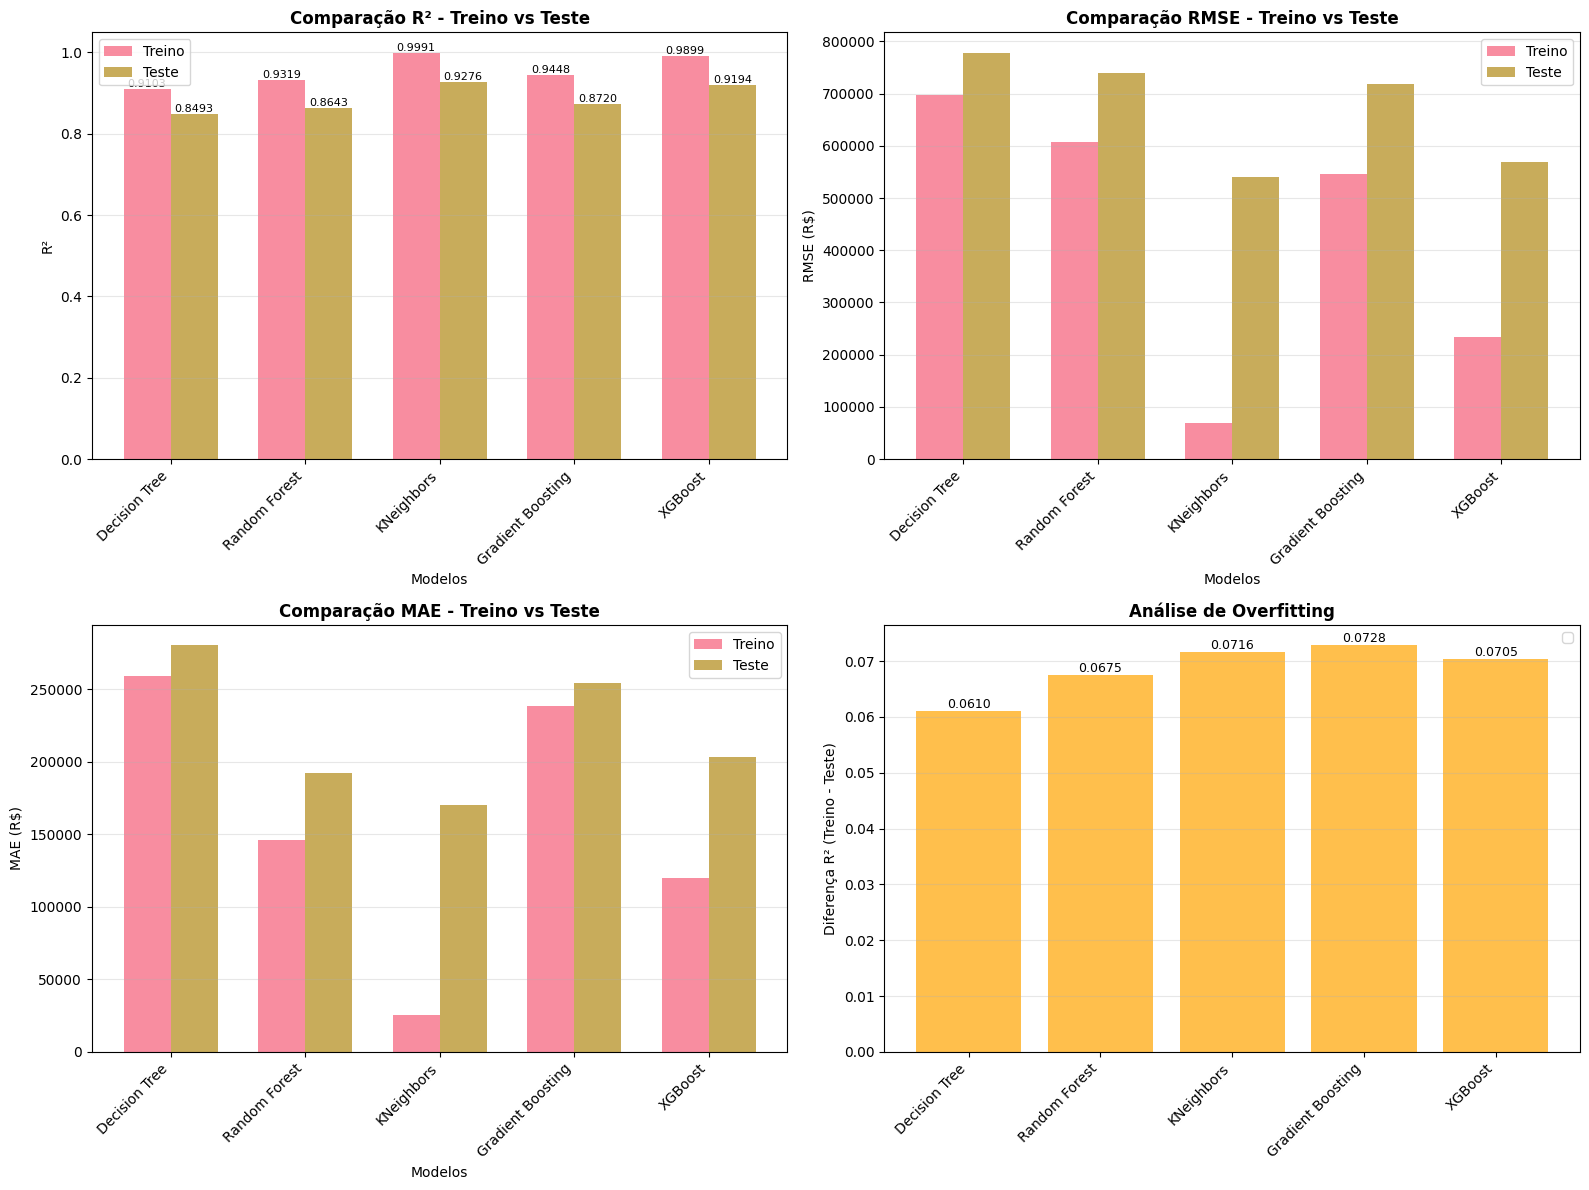

Gráficos de comparação das métricas entre os modelos.


In [84]:
# Comparação de R² entre modelos
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Gráfico de R² Comparativo
modelos = list(resultados_modelos.keys())
r2_treino_vals = [resultados_modelos[m]['metricas_treino']['R2'] for m in modelos]
r2_teste_vals = [resultados_modelos[m]['metricas_teste']['R2'] for m in modelos]

x = np.arange(len(modelos))
width = 0.35

ax1 = axes[0, 0]
bars1 = ax1.bar(x - width/2, r2_treino_vals, width, label='Treino', alpha=0.8)
bars2 = ax1.bar(x + width/2, r2_teste_vals, width, label='Teste', alpha=0.8)
ax1.set_xlabel('Modelos')
ax1.set_ylabel('R²')
ax1.set_title('Comparação R² - Treino vs Teste', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(modelos, rotation=45, ha='right')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Adicionar valores nas barras
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}', ha='center', va='bottom', fontsize=8)

# 2. Gráfico de RMSE Comparativo
rmse_treino_vals = [resultados_modelos[m]['metricas_treino']['RMSE'] for m in modelos]
rmse_teste_vals = [resultados_modelos[m]['metricas_teste']['RMSE'] for m in modelos]

ax2 = axes[0, 1]
bars1 = ax2.bar(x - width/2, rmse_treino_vals, width, label='Treino', alpha=0.8)
bars2 = ax2.bar(x + width/2, rmse_teste_vals, width, label='Teste', alpha=0.8)
ax2.set_xlabel('Modelos')
ax2.set_ylabel('RMSE (R$)')
ax2.set_title('Comparação RMSE - Treino vs Teste', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(modelos, rotation=45, ha='right')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# 3. Gráfico de MAE Comparativo
mae_treino_vals = [resultados_modelos[m]['metricas_treino']['MAE'] for m in modelos]
mae_teste_vals = [resultados_modelos[m]['metricas_teste']['MAE'] for m in modelos]

ax3 = axes[1, 0]
bars1 = ax3.bar(x - width/2, mae_treino_vals, width, label='Treino', alpha=0.8)
bars2 = ax3.bar(x + width/2, mae_teste_vals, width, label='Teste', alpha=0.8)
ax3.set_xlabel('Modelos')
ax3.set_ylabel('MAE (R$)')
ax3.set_title('Comparação MAE - Treino vs Teste', fontsize=12, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(modelos, rotation=45, ha='right')
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

# 4. Diferença R² (Overfitting Analysis)
diff_r2_vals = [resultados_modelos[m]['metricas_treino']['R2'] - resultados_modelos[m]['metricas_teste']['R2'] 
                for m in modelos]

ax4 = axes[1, 1]
colors = ['green' if d < 0.05 else 'orange' if d < 0.1 else 'red' for d in diff_r2_vals]
bars = ax4.bar(modelos, diff_r2_vals, color=colors, alpha=0.7)
ax4.set_ylabel('Diferença R² (Treino - Teste)')
ax4.set_title('Análise de Overfitting', fontsize=12, fontweight='bold')
ax4.set_xticklabels(modelos, rotation=45, ha='right')
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

# Adicionar valores nas barras
for bar in bars:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("Gráficos de comparação das métricas entre os modelos.")

## 14.1 Real vs Predito

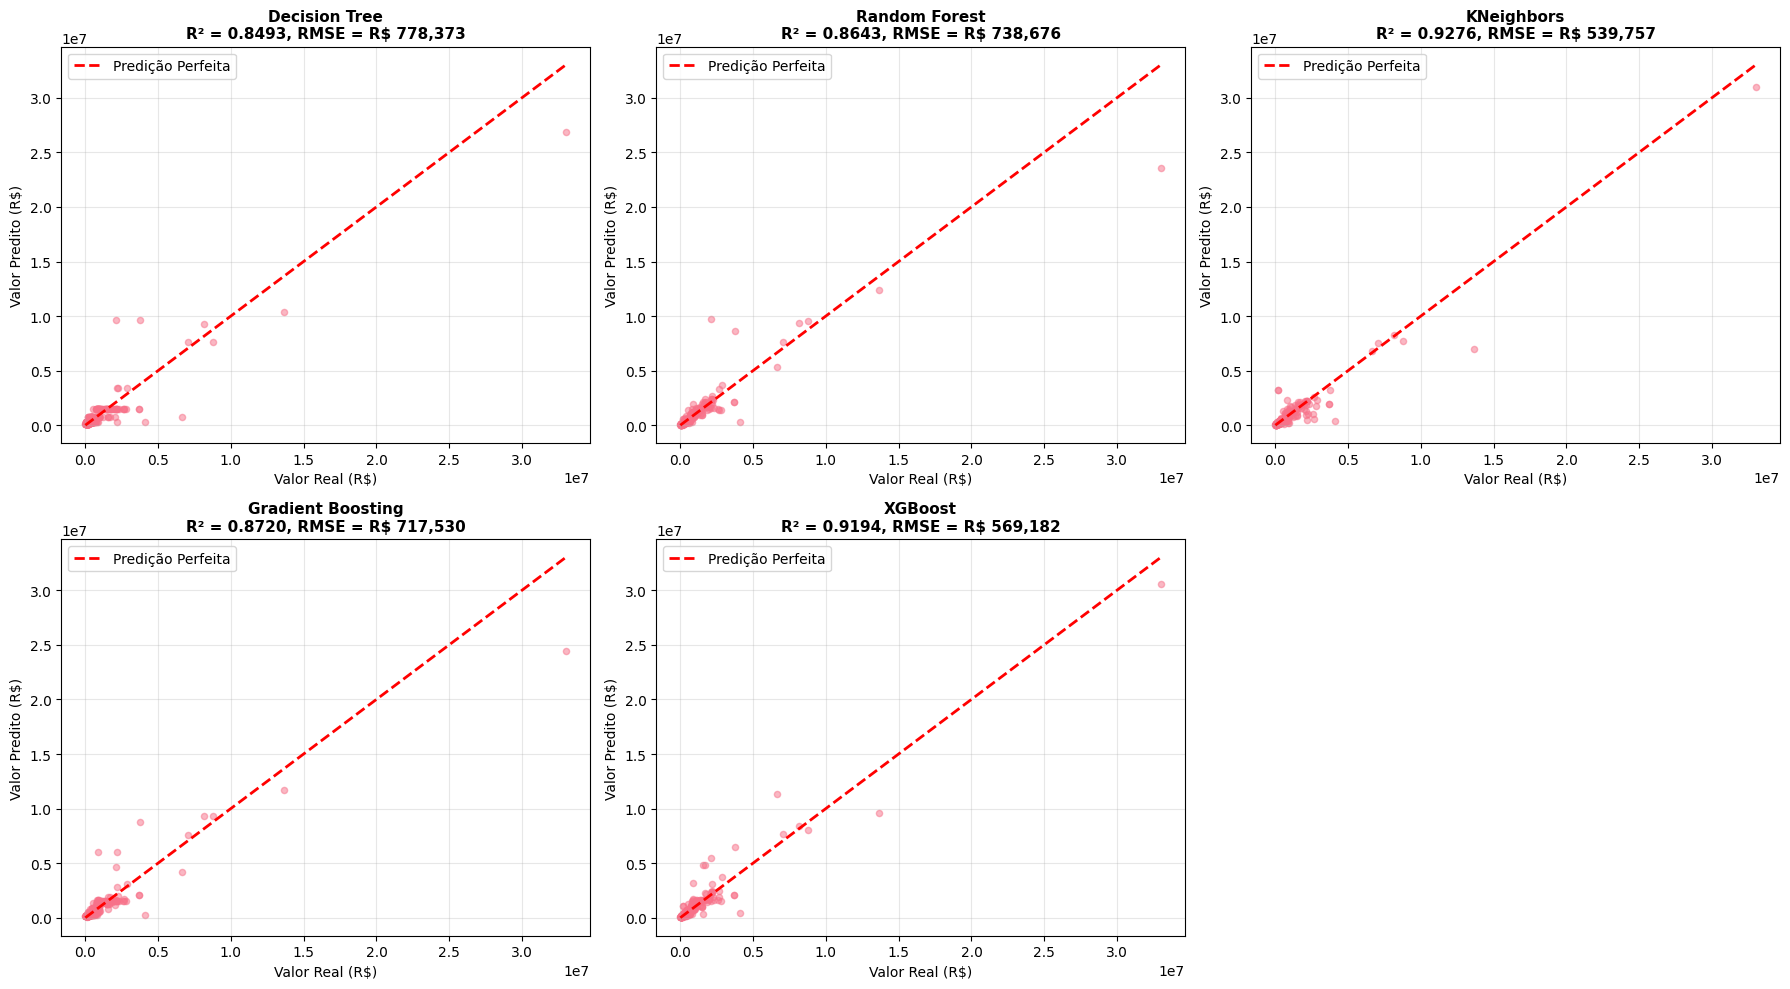

Gráficos Real vs Predito


In [85]:
# Gráficos de Real vs Predito para cada modelo
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (nome_modelo, resultado) in enumerate(resultados_modelos.items()):
    ax = axes[idx]
    y_pred = resultado['y_pred_teste']
    
    # Scatter plot
    ax.scatter(y_teste, y_pred, alpha=0.5, s=20)
    
    # Linha diagonal (predição perfeita)
    min_val = min(y_teste.min(), y_pred.min())
    max_val = max(y_teste.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Predição Perfeita')
    
    # Labels e título
    r2 = resultado['metricas_teste']['R2']
    rmse = resultado['metricas_teste']['RMSE']
    ax.set_xlabel('Valor Real (R$)')
    ax.set_ylabel('Valor Predito (R$)')
    ax.set_title(f'{nome_modelo}\nR² = {r2:.4f}, RMSE = R$ {rmse:,.0f}', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend()

# Remover se houver subplots vazios
if len(resultados_modelos) < 6:
    fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

print("Gráficos Real vs Predito")

## 14.2 - Análise de Resíduos

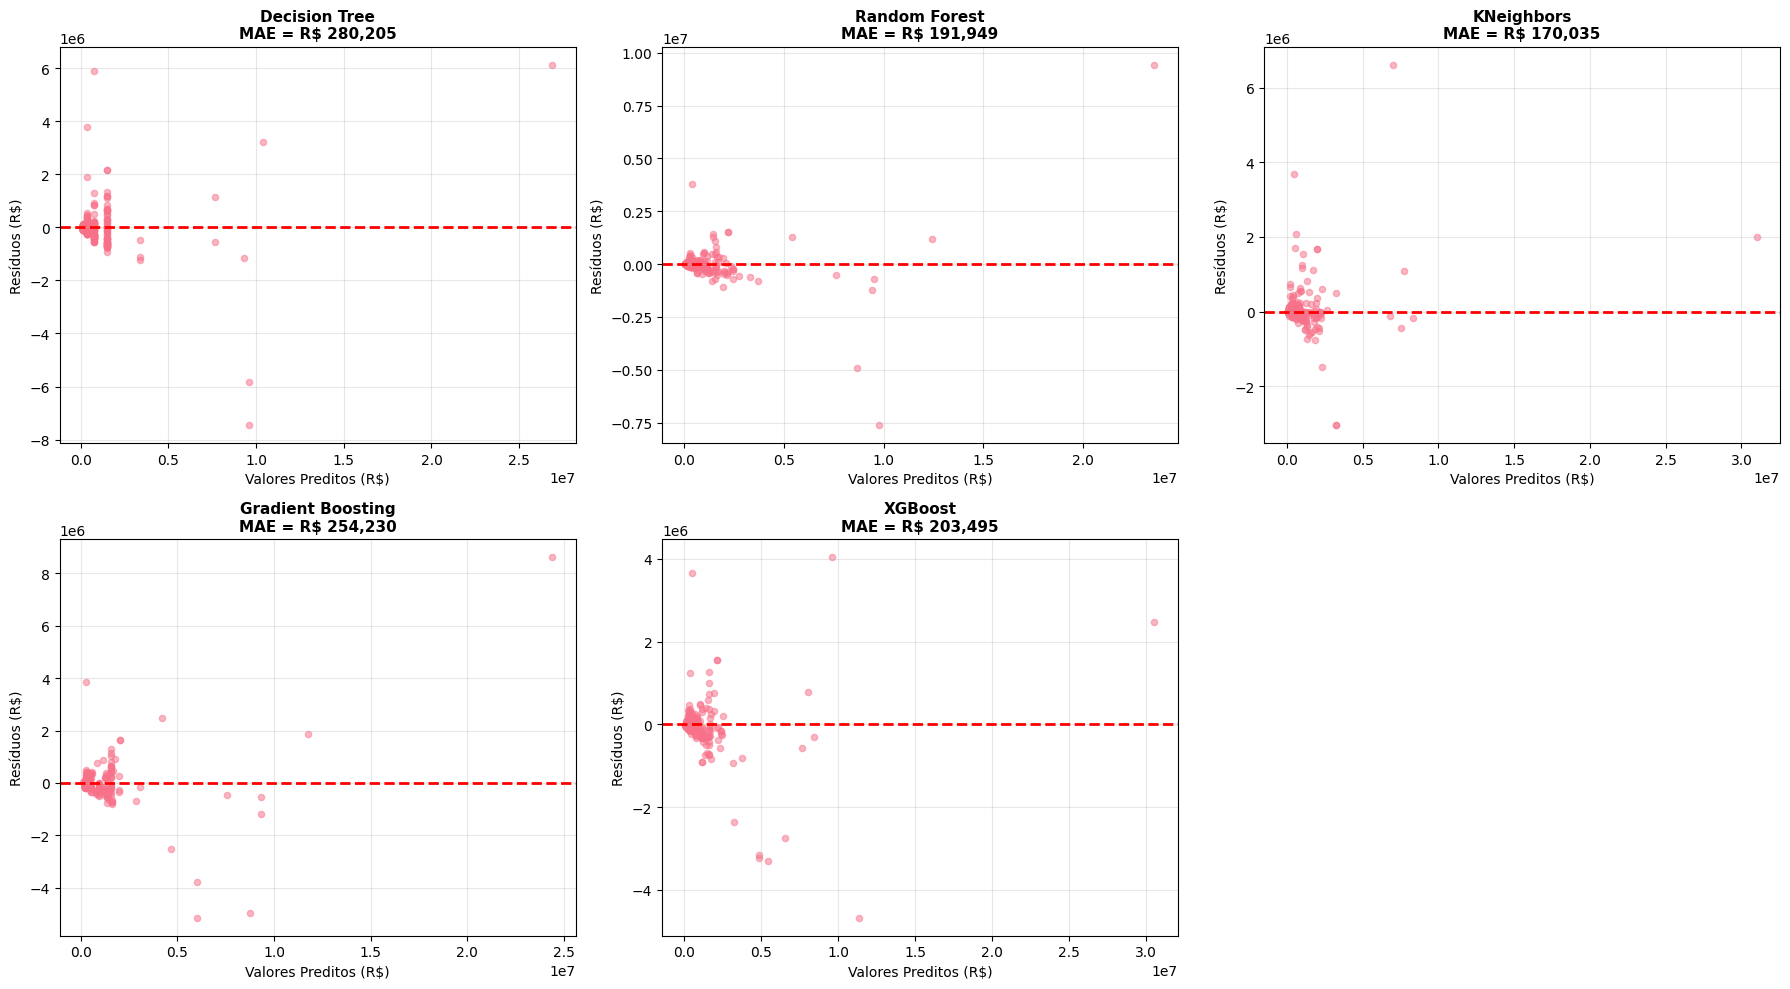

Gráficos de Resíduos


In [86]:
# Análise de Resíduos (Erros de Predição)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (nome_modelo, resultado) in enumerate(resultados_modelos.items()):
    ax = axes[idx]
    y_pred = resultado['y_pred_teste']
    
    # Calcular resíduos
    residuos = y_teste - y_pred
    
    # Scatter plot de resíduos
    ax.scatter(y_pred, residuos, alpha=0.5, s=20)
    ax.axhline(y=0, color='r', linestyle='--', lw=2)
    
    # Labels e título
    mae = resultado['metricas_teste']['MAE']
    rmse = resultado['metricas_teste']['RMSE']
    ax.set_xlabel('Valores Preditos (R$)')
    ax.set_ylabel('Resíduos (R$)')
    ax.set_title(f'{nome_modelo}\nMAE = R$ {mae:,.0f}', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)

# Remover se houver subplots vazios
if len(resultados_modelos) < 6:
    fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

print("Gráficos de Resíduos")

## 15. Comparação dos modelos base

In [87]:
print("SEÇÃO I: COMPARAÇÃO INICIAL DE TODOS OS MODELOS BASE")

# Consolidar métricas de todos os modelos base
print(f"\n{'MODELO':<20} {'R² Treino':<15} {'R² Teste':<15} {'Diferença':<15} {'RMSE Teste':<20} {'MAE Teste':<20} {'MAPE Teste':<15}")
print("-" * 130)

modelos_base_info = {
    'Decision Tree': {'treino': metricas_treino_dt['R2'], 'teste': metricas_teste_dt['R2'], 'rmse': metricas_teste_dt['RMSE'], 'mae': metricas_teste_dt['MAE'], 'mape': metricas_teste_dt['MAPE'] * 100},
    'Random Forest': {'treino': metricas_treino_rf['R2'], 'teste': metricas_teste_rf['R2'], 'rmse': metricas_teste_rf['RMSE'], 'mae': metricas_teste_rf['MAE'], 'mape': metricas_teste_rf['MAPE'] * 100},
    'KNN': {'treino': metricas_treino_knn['R2'], 'teste': metricas_teste_knn['R2'], 'rmse': metricas_teste_knn['RMSE'], 'mae': metricas_teste_knn['MAE'], 'mape': metricas_teste_knn['MAPE'] * 100},
    'Gradient Boosting': {'treino': metricas_treino_gb['R2'], 'teste': metricas_teste_gb['R2'], 'rmse': metricas_teste_gb['RMSE'], 'mae': metricas_teste_gb['MAE'], 'mape': metricas_teste_gb['MAPE'] * 100},
    'XGBoost': {'treino': metricas_treino_xgb['R2'], 'teste': metricas_teste_xgb['R2'], 'rmse': metricas_teste_xgb['RMSE'], 'mae': metricas_teste_xgb['MAE'], 'mape': metricas_teste_xgb['MAPE'] * 100}
}

for modelo_nome, metricas in modelos_base_info.items():
    diff = metricas['treino'] - metricas['teste']
    print(f"{modelo_nome:<20} {metricas['treino']:<15.6f} {metricas['teste']:<15.6f} {diff:<15.6f} R$ {metricas['rmse']:<18.2f} R$ {metricas['mae']:<18.2f} {metricas['mape']:<15.2f}%")


SEÇÃO I: COMPARAÇÃO INICIAL DE TODOS OS MODELOS BASE

MODELO               R² Treino       R² Teste        Diferença       RMSE Teste           MAE Teste            MAPE Teste     
----------------------------------------------------------------------------------------------------------------------------------
Decision Tree        0.910329        0.849346        0.060983        R$ 778373.04          R$ 280205.22          47.05          %
Random Forest        0.931857        0.864321        0.067536        R$ 738676.30          R$ 191948.77          22.29          %
KNN                  0.999123        0.927556        0.071567        R$ 539756.51          R$ 170035.05          27.72          %
Gradient Boosting    0.944801        0.871978        0.072823        R$ 717530.08          R$ 254230.19          51.58          %
XGBoost              0.989909        0.919442        0.070466        R$ 569181.96          R$ 203494.82          29.68          %


## 16. Fine-Tuning individual de cada modelo


In [88]:
# Armazenar os modelos com melhores hiperparâmetros (considera se FT melhora ou não)
melhores_modelos = {}
historico_finetuning = {}

# Definir param_grids para fine-tuning de cada modelo, em torno dos melhores hiperparâmetros encontrados na etapa anterior
param_grids_ft = {
    'Decision Tree': {
        'model__max_depth': [3, 4, 5, 6, 7],
        'model__min_samples_split': [6, 8, 10, 12, 14],
        'model__min_samples_leaf': [1, 2, 3, 4]
    },
    'Random Forest': {
        'model__n_estimators': [250, 300, 350],
        'model__max_depth': [25, 30, 35],
        'model__min_samples_split': [2, 3, 4],
        'model__min_samples_leaf': [1, 2],
        'model__max_features': [0.65, 0.7, 0.75]
    },
    'KNN': {
        'model__n_neighbors': [5, 7, 9, 11, 13, 15],
        'model__weights': ['uniform', 'distance'],
        'model__p': [1, 2]
    },
    'Gradient Boosting': {
        'model__n_estimators': [80, 100, 120, 150],
        'model__learning_rate': [0.03, 0.05, 0.07],
        'model__max_depth': [3, 4, 5],
        'model__min_samples_split': [8, 10, 12, 14],
        'model__min_samples_leaf': [1, 2, 3],
        'model__subsample': [0.7, 0.8, 0.9]
    },
    'XGBoost': {
        'model__n_estimators': [200, 300, 400],
        'model__learning_rate': [0.03, 0.05, 0.07],
        'model__max_depth': [2, 3, 4],
        'model__subsample': [0.6, 0.7, 0.8],
        'model__colsample_bytree': [0.7, 0.8, 0.9]
    }
}

# Usar os modelos base já treinados (grid_search_*)
grid_searches_originais = {
    'Decision Tree': grid_search_dt,
    'Random Forest': grid_search_rf,
    'KNN': grid_search_knn,
    'Gradient Boosting': grid_search_gb,
    'XGBoost': grid_search_xgb
}

# Métricas originais para comparação
metricas_originais = {
    'Decision Tree': metricas_teste_dt,
    'Random Forest': metricas_teste_rf,
    'KNN': metricas_teste_knn,
    'Gradient Boosting': metricas_teste_gb,
    'XGBoost': metricas_teste_xgb
}

# Executar fine-tuning para cada modelo
for modelo_nome, param_grid_ft in param_grids_ft.items():
    print(f"\n{'='*150}")
    print(f"  FINE-TUNING: {modelo_nome.upper()}")
    print(f"{'='*150}")
    
    # Obter modelo base
    grid_search_base = grid_searches_originais[modelo_nome]
    modelo_base = grid_search_base.best_estimator_
    
    # GridSearchCV com fine-tuning
    grid_search_ft = GridSearchCV(
        estimator=modelo_base,
        param_grid=param_grid_ft,
        cv=5,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1,
        verbose=0
    )
    
    print(f"Executando GridSearchCV (5-fold CV)...", end=" ")
    grid_search_ft.fit(X_treino, y_treino)
        
    # Modelo fine-tuned
    modelo_ft = grid_search_ft.best_estimator_
    
    # Predições no teste
    y_teste_pred_ft = modelo_ft.predict(X_teste)
    metricas_ft_teste = calcular_metricas(y_teste, y_teste_pred_ft)
    
    # Comparação antes vs depois
    print(f"\n Comparação entre modelo original e modelo após fine tuning:")
    print(f"{'Métrica':<15} {'Antes':<20} {'Depois':<20} {'Diferença':<20} {'Status':<15}")
    print("-" * 90)
    
    r2_diff = metricas_ft_teste['R2'] - metricas_originais[modelo_nome]['R2']
    rmse_diff = metricas_originais[modelo_nome]['RMSE'] - metricas_ft_teste['RMSE']
    mae_diff = metricas_originais[modelo_nome]['MAE'] - metricas_ft_teste['MAE']
    mape_diff = metricas_originais[modelo_nome]['MAPE'] - metricas_ft_teste['MAPE']
    
    r2_status = "✓ Melhorou" if r2_diff > 0.001 else "✗ Piorou" if r2_diff < -0.001 else "→ Igual"
    rmse_status = "✓ Melhorou" if rmse_diff > 0 else "✗ Piorou" if rmse_diff < 0 else "→ Igual"
    mae_status = "✓ Melhorou" if mae_diff > 0 else "✗ Piorou" if mae_diff < 0 else "→ Igual"
    mape_status = "✓ Melhorou" if mape_diff > 0.01 else "✗ Piorou" if mape_diff < -0.01 else "→ Igual"
    
    print(f"{'R²':<15} {metricas_originais[modelo_nome]['R2']:<20.6f} {metricas_ft_teste['R2']:<20.6f} {r2_diff:+.6f}{'':<6} {r2_status:<15}")
    print(f"{'RMSE (R$)':<15} {metricas_originais[modelo_nome]['RMSE']:<20.2f} {metricas_ft_teste['RMSE']:<20.2f} {rmse_diff:+.2f}{'':<10} {rmse_status:<15}")
    print(f"{'MAE (R$)':<15} {metricas_originais[modelo_nome]['MAE']:<20.2f} {metricas_ft_teste['MAE']:<20.2f} {mae_diff:+.2f}{'':<10} {mae_status:<15}")
    print(f"{'MAPE':<15} {metricas_originais[modelo_nome]['MAPE']:<20.6f} {metricas_ft_teste['MAPE']:<20.6f} {mape_diff:+.6f}{'':<10} {mape_status:<15}")
    
    print(f"\n Melhores Hiperparâmetros (Fine-Tuning):")
    for param, valor in grid_search_ft.best_params_.items():
        print(f"   • {param}: {valor}")
    print(f"   • CV RMSE: {-grid_search_ft.best_score_:.6f}")
    
    # Decisão: análise holística de TODAS as métricas
    metricas_melhoraram = 0
    metricas_pioraram = 0
    
    # Contar melhorias/pioras em cada métrica
    if r2_diff > 0.001: metricas_melhoraram += 1
    elif r2_diff < -0.001: metricas_pioraram += 1
        
    if rmse_diff > 0: metricas_melhoraram += 1
    elif rmse_diff < 0: metricas_pioraram += 1
        
    if mae_diff > 0: metricas_melhoraram += 1
    elif mae_diff < 0: metricas_pioraram += 1
        
    if mape_diff > 0.01: metricas_melhoraram += 1
    elif mape_diff < -0.01: metricas_pioraram += 1
    
    # Decisão baseada em maioria das métricas (com peso para R²)
    usar_ft = False
    mensagem = ""
    
    if metricas_melhoraram >= 3:  # 3 ou 4 métricas melhoraram
        usar_ft = True
        mensagem = f"  CONCLUSÃO: Fine-tuning MELHOROU o modelo! ({metricas_melhoraram}/4 métricas melhoraram)"
        mensagem += f"\n   → O modelo refinado foi selecionado para as etapas subsequentes"
    elif metricas_melhoraram == 2 and r2_diff > 0:  # 2 métricas melhoraram E R² melhorou
        usar_ft = True
        mensagem = f"  CONCLUSÃO: Fine-tuning mostrou melhoria relevante! ({metricas_melhoraram}/4 métricas melhoraram)"
        mensagem += f"\n   → R² (principal métrica) melhorou, o modelo refinado foi selecionado para as etapas subsequentes"
    elif metricas_melhoraram == 1 and r2_diff > 0.005:  # Apenas R² melhorou significativamente
        usar_ft = True
        mensagem = f"   CONCLUSÃO: Fine-tuning melhorou principalmente R² (+{r2_diff:.6f})"
        mensagem += f"\n   → O modelo refinado foi selecionado para as etapas subsequentes (com ressalva sobre outras métricas)"
    else:
        mensagem = f"  CONCLUSÃO: Fine-tuning NÃO melhorou globalmente"
        mensagem += f"\n   → Métricas melhoradas: {metricas_melhoraram}/4 | Pioradas: {metricas_pioraram}/4"
        mensagem += f"\n   → Será mantido modelo original"
    
    print(f"\n{mensagem}")
    
    if usar_ft:
        print(f"   • Novo R²: {metricas_ft_teste['R2']:.6f} (Original: {metricas_originais[modelo_nome]['R2']:.6f})")
        print(f"   • Novo RMSE: R${metricas_ft_teste['RMSE']:.2f} (Original: R${metricas_originais[modelo_nome]['RMSE']:.2f})")
        print(f"   • Novo MAE: R${metricas_ft_teste['MAE']:.2f} (Original: R${metricas_originais[modelo_nome]['MAE']:.2f})")
        print(f"   • Novo MAPE: {metricas_ft_teste['MAPE']:.2f} (Original: {metricas_originais[modelo_nome]['MAPE']:.2f})")
        melhores_modelos[modelo_nome] = modelo_ft
        historico_finetuning[modelo_nome] = {
            'melhorou': True,
            'metricas_original': metricas_originais[modelo_nome],
            'metricas_ft': metricas_ft_teste,
            'melhoria_r2': r2_diff,
            'metricas_melhoraram': metricas_melhoraram
        }
    else:
        print(f"   • Mantendo R² Original: {metricas_originais[modelo_nome]['R2']:.6f}")
        historico_finetuning[modelo_nome] = {
            'melhorou': False,
            'metricas_original': metricas_originais[modelo_nome],
            'metricas_ft': metricas_ft_teste,
            'melhoria_r2': r2_diff,
            'metricas_melhoraram': metricas_melhoraram
        }
        melhores_modelos[modelo_nome] = grid_search_base.best_estimator_
        historico_finetuning[modelo_nome] = {
            'melhorou': False,
            'metricas_original': metricas_originais[modelo_nome],
            'metricas_ft': metricas_ft_teste,
            'melhoria_r2': r2_diff
        }




  FINE-TUNING: DECISION TREE
Executando GridSearchCV (5-fold CV)... 
 Comparação entre modelo original e modelo após fine tuning:
Métrica         Antes                Depois               Diferença            Status         
------------------------------------------------------------------------------------------
R²              0.849346             0.849346             +0.000000       → Igual        
RMSE (R$)       778373.04            778373.04            +0.00           → Igual        
MAE (R$)        280205.22            280205.22            +0.00           → Igual        
MAPE            0.470452             0.470452             +0.000000           → Igual        

 Melhores Hiperparâmetros (Fine-Tuning):
   • model__max_depth: 5
   • model__min_samples_leaf: 1
   • model__min_samples_split: 10
   • CV RMSE: 1347053.273074

  CONCLUSÃO: Fine-tuning NÃO melhorou globalmente
   → Métricas melhoradas: 0/4 | Pioradas: 0/4
   → Será mantido modelo original
   • Mantendo R² Original:

## 17. Consolidação dos melhores hiperparâmetros

In [89]:
# Resumo do fine-tuning para todos os modelos
print(f"\n{'Modelo':<20} {'Fine-Tuning':<20} {'R² Original':<18} {'R² Final':<18} {'Melhoria':<18}")
print("-" * 95)

for modelo_nome, info in historico_finetuning.items():
    status = "✓ Melhorado" if info['melhorou'] else "✗ Mantido"
    r2_original = info['metricas_original']['R2']
    r2_final = info['metricas_ft']['R2'] if info['melhorou'] else info['metricas_original']['R2']
    melhoria = ((r2_final - r2_original) / r2_original * 100) if r2_original != 0 else 0
    
    print(f"{modelo_nome:<20} {status:<20} {r2_original:<18.6f} {r2_final:<18.6f} {melhoria:+.2f}%")



Modelo               Fine-Tuning          R² Original        R² Final           Melhoria          
-----------------------------------------------------------------------------------------------
Decision Tree        ✗ Mantido            0.849346           0.849346           +0.00%
Random Forest        ✓ Melhorado          0.864321           0.896891           +3.77%
KNN                  ✗ Mantido            0.927556           0.927556           +0.00%
Gradient Boosting    ✓ Melhorado          0.871978           0.912741           +4.67%
XGBoost              ✗ Mantido            0.919442           0.919442           +0.00%


## 18. Validação Cruzada Robusta (10-Fold) com melhores hiperparâmetros

In [90]:

k_folds = 10
kfold = KFold(n_splits=k_folds, shuffle=True, random_state=42)

contador_fits = 0
resultados_cv_todos = {}

print(f"\nExecutando {k_folds}-Fold Cross Validation em cada modelo...\n")

for modelo_nome, modelo_best in melhores_modelos.items():
    print(f"⏳ {modelo_nome}...", end=" ")
    
    r2_treino_vals = []
    r2_teste_vals = []
    rmse_treino_vals = []
    rmse_teste_vals = []
    mae_treino_vals = []
    mae_teste_vals = []
    
    for train_idx, test_idx in kfold.split(X_treino):
        contador_fits += 1
        # Se X_treino for DataFrame
        X_fold_train = X_treino.iloc[train_idx]
        X_fold_test = X_treino.iloc[test_idx]
        y_fold_train = y_treino.iloc[train_idx]
        y_fold_test = y_treino.iloc[test_idx]
        
        # Clonar modelo para cada fold
        modelo_fold = clone(modelo_best)
        modelo_fold.fit(X_fold_train, y_fold_train)
        
        # Predições
        y_fold_train_pred = modelo_fold.predict(X_fold_train)
        y_fold_test_pred = modelo_fold.predict(X_fold_test)
        
        # Métricas
        r2_treino = r2_score(y_fold_train, y_fold_train_pred)
        r2_teste = r2_score(y_fold_test, y_fold_test_pred)
        rmse_treino = np.sqrt(mean_squared_error(y_fold_train, y_fold_train_pred))
        rmse_teste = np.sqrt(mean_squared_error(y_fold_test, y_fold_test_pred))
        mae_treino = mean_absolute_error(y_fold_train, y_fold_train_pred)
        mae_teste = mean_absolute_error(y_fold_test, y_fold_test_pred)
        
        r2_treino_vals.append(r2_treino)
        r2_teste_vals.append(r2_teste)
        rmse_treino_vals.append(rmse_treino)
        rmse_teste_vals.append(rmse_teste)
        mae_treino_vals.append(mae_treino)
        mae_teste_vals.append(mae_teste)
    
    resultados_cv_todos[modelo_nome] = {
        'r2_train': np.array(r2_treino_vals),
        'r2_test': np.array(r2_teste_vals),
        'rmse_train': np.array(rmse_treino_vals),
        'rmse_test': np.array(rmse_teste_vals),
        'mae_train': np.array(mae_treino_vals),
        'mae_test': np.array(mae_teste_vals),
    }



print("RESULTADOS DETALHADOS DA VALIDAÇÃO CRUZADA")

print(f"{'Modelo':<20} {'R² Média':<15} {'R² Desvio':<15} {'RMSE Média':<18} {'RMSE Desvio':<18} {'MAE Média':<15} {'MAE Desvio':<15}")
print("-" * 150)

for modelo_nome, metrics in resultados_cv_todos.items():
    print(f"{modelo_nome:<20} "
          f"{metrics['r2_test'].mean():<15.6f} "
          f"{metrics['r2_test'].std():<15.6f} "
          f"{metrics['rmse_test'].mean():<18.2f} "
          f"{metrics['rmse_test'].std():<18.2f} "
          f"{metrics['mae_test'].mean():<15.2f} "
          f"{metrics['mae_test'].std():<15.2f}")


print("Total de fits esperados:", contador_fits)


Executando 10-Fold Cross Validation em cada modelo...

⏳ Decision Tree... ⏳ Random Forest... ⏳ KNN... ⏳ Gradient Boosting... ⏳ XGBoost... RESULTADOS DETALHADOS DA VALIDAÇÃO CRUZADA
Modelo               R² Média        R² Desvio       RMSE Média         RMSE Desvio        MAE Média       MAE Desvio     
------------------------------------------------------------------------------------------------------------------------------------------------------
Decision Tree        0.477570        0.391537        1221501.54         665441.84          352577.43       119425.11      
Random Forest        0.700833        0.217965        1016590.77         830271.85          270530.47       155277.22      
KNN                  0.561895        0.229508        1326921.76         985444.33          322972.43       177940.27      
Gradient Boosting    0.672764        0.216475        1065363.97         782182.03          334123.73       136377.50      
XGBoost              0.689573        0.218079       

## 19. Comparação Visual e Análise de Resultados

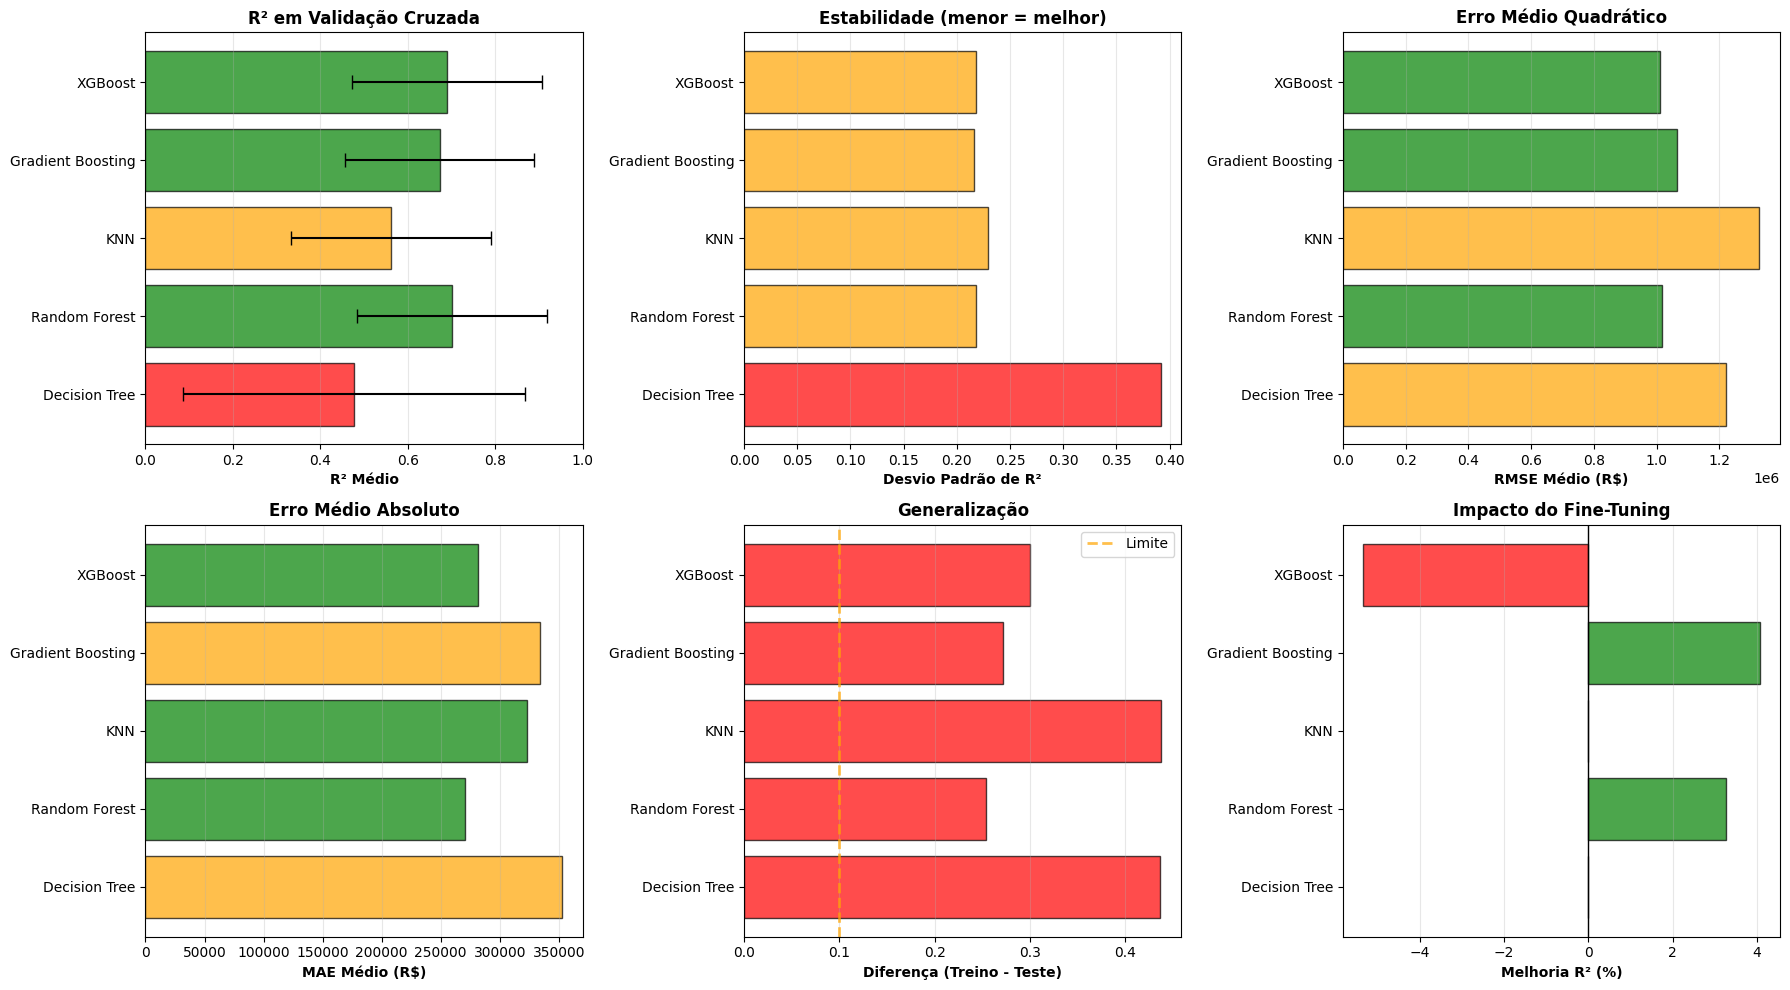


✓ Gráficos de em validação cruzada gerados com sucesso!


In [91]:

# Criar visualizações comparativas
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. R² Médio em CV
ax1 = axes[0, 0]
modelos = list(resultados_cv_todos.keys())
r2_medios = [resultados_cv_todos[m]['r2_test'].mean() for m in modelos]
r2_desvios = [resultados_cv_todos[m]['r2_test'].std() for m in modelos]

cores = ['green' if r > 0.65 else 'orange' if r > 0.55 else 'red' for r in r2_medios]
bars1 = ax1.barh(modelos, r2_medios, color=cores, alpha=0.7, edgecolor='black')
ax1.errorbar(r2_medios, modelos, xerr=r2_desvios, fmt='none', color='black', capsize=5)
ax1.set_xlabel('R² Médio', fontweight='bold')
ax1.set_title('R² em Validação Cruzada', fontweight='bold')
ax1.set_xlim(0, 1)
ax1.grid(alpha=0.3, axis='x')

# 2. Desvio Padrão (Estabilidade)
ax2 = axes[0, 1]
r2_desvios_vals = [resultados_cv_todos[m]['r2_test'].std() for m in modelos]
cores2 = ['green' if d < 0.15 else 'orange' if d < 0.25 else 'red' for d in r2_desvios_vals]
ax2.barh(modelos, r2_desvios_vals, color=cores2, alpha=0.7, edgecolor='black')
ax2.set_xlabel('Desvio Padrão de R²', fontweight='bold')
ax2.set_title('Estabilidade (menor = melhor)', fontweight='bold')
ax2.grid(alpha=0.3, axis='x')

# 3. RMSE Médio
ax3 = axes[0, 2]
rmse_medios = [resultados_cv_todos[m]['rmse_test'].mean() for m in modelos]
cores3 = ['green' if r < 1200000 else 'orange' if r < 1400000 else 'red' for r in rmse_medios]
ax3.barh(modelos, rmse_medios, color=cores3, alpha=0.7, edgecolor='black')
ax3.set_xlabel('RMSE Médio (R$)', fontweight='bold')
ax3.set_title('Erro Médio Quadrático', fontweight='bold')
ax3.grid(alpha=0.3, axis='x')

# 4. MAE Médio
ax4 = axes[1, 0]
mae_medios = [resultados_cv_todos[m]['mae_test'].mean() for m in modelos]
cores4 = ['green' if m < 330000 else 'orange' if m < 400000 else 'red' for m in mae_medios]
ax4.barh(modelos, mae_medios, color=cores4, alpha=0.7, edgecolor='black')
ax4.set_xlabel('MAE Médio (R$)', fontweight='bold')
ax4.set_title('Erro Médio Absoluto', fontweight='bold')
ax4.grid(alpha=0.3, axis='x')

# 5. Diferença Treino-Teste (Generalização)
ax5 = axes[1, 1]
diff_vals = [resultados_cv_todos[m]['r2_train'].mean() - resultados_cv_todos[m]['r2_test'].mean() for m in modelos]
cores5 = ['green' if d < 0.10 else 'orange' if d < 0.20 else 'red' for d in diff_vals]
ax5.barh(modelos, diff_vals, color=cores5, alpha=0.7, edgecolor='black')
ax5.axvline(x=0.1, color='orange', linestyle='--', linewidth=2, alpha=0.7, label='Limite')
ax5.set_xlabel('Diferença (Treino - Teste)', fontweight='bold')
ax5.set_title('Generalização', fontweight='bold')
ax5.grid(alpha=0.3, axis='x')
ax5.legend()

# 6. Comparação de Fine-Tuning
ax6 = axes[1, 2]
melhorias_ft = []
for modelo_nome in modelos:
    if historico_finetuning[modelo_nome]['melhorou']:
        melhoria = historico_finetuning[modelo_nome]['melhoria_r2']
    else:
        melhoria = historico_finetuning[modelo_nome]['melhoria_r2']
    melhorias_ft.append(melhoria * 100)

cores6 = ['green' if m > 0 else 'red' for m in melhorias_ft]
ax6.barh(modelos, melhorias_ft, color=cores6, alpha=0.7, edgecolor='black')
ax6.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax6.set_xlabel('Melhoria R² (%)', fontweight='bold')
ax6.set_title('Impacto do Fine-Tuning', fontweight='bold')
ax6.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\n✓ Gráficos de em validação cruzada gerados com sucesso!")

## 20. ANÁLISE FINAL E CONCLUSÃO ACADÊMICA

In [92]:
print("ANÁLISE FINAL CONSOLIDADA: MATRIZ DE DECISÃO PARA SELEÇÃO DO MELHOR MODELO")

# Criar matriz de decisão
dados_decisao = []

for modelo_nome in resultados_cv_todos.keys():
    cv_r2_mean = resultados_cv_todos[modelo_nome]['r2_test'].mean()
    cv_r2_std = resultados_cv_todos[modelo_nome]['r2_test'].std()
    cv_rmse_mean = resultados_cv_todos[modelo_nome]['rmse_test'].mean()
    cv_mae_mean = resultados_cv_todos[modelo_nome]['mae_test'].mean()
    
    # Diferença treino-teste para análise de overfitting
    diff_r2 = resultados_cv_todos[modelo_nome]['r2_train'].mean() - resultados_cv_todos[modelo_nome]['r2_test'].mean()
    
    # Status FT
    ft_status = "Melhorou" if historico_finetuning[modelo_nome]['melhorou'] else "Mantido"
    
    # Scores de qualidade
    score_r2 = 1 if cv_r2_mean > 0.70 else (2 if cv_r2_mean > 0.60 else 3)
    score_estab = 1 if cv_r2_std < 0.15 else (2 if cv_r2_std < 0.25 else 3)
    score_overf = 1 if diff_r2 < 0.10 else (2 if diff_r2 < 0.20 else 3)
    score_rmse = 1 if cv_rmse_mean < 1200000 else (2 if cv_rmse_mean < 1400000 else 3)
    score_mae = 1 if cv_mae_mean < 330000 else (2 if cv_mae_mean < 400000 else 3)
    
    # Pontuação total (quanto menor, melhor)
    score_total = score_r2 + score_estab + score_overf + score_rmse + score_mae
    
    dados_decisao.append({
        'Modelo': modelo_nome,
        'R² CV': cv_r2_mean,
        'Desvio R²': cv_r2_std,
        'RMSE (R$)': cv_rmse_mean,
        'MAE (R$)': cv_mae_mean,
        'Overfit': diff_r2,
        'FT': ft_status,
        'Pontuação': score_total
    })

df_decisao = pd.DataFrame(dados_decisao)
df_decisao = df_decisao.sort_values('Pontuação')

print(f"\n{'Modelo':<20} {'R² CV':<12} {'Desvio':<12} {'RMSE':<18} {'MAE':<18} {'Overfit':<12} {'Score':<8}")
print("-" * 120)

for idx, row in df_decisao.iterrows():
    print(f"{row['Modelo']:<20} {row['R² CV']:<12.6f} {row['Desvio R²']:<12.6f} R${row['RMSE (R$)']:<16.0f} R${row['MAE (R$)']:<16.0f} {row['Overfit']:<12.6f} {int(row['Pontuação']):<8}")


# Determinier o melhor modelo
melhor_modelo_col = df_decisao.iloc[0]


print(f"🏆 RECOMENDAÇÃO FINAL")

print(f"""
  MELHOR MODELO RECOMENDADO: **{melhor_modelo_col['Modelo'].upper()}**

  MÉTRICAS FINAIS:
   • R² em Validação Cruzada: {melhor_modelo_col['R² CV']:.6f}
   • Desvio Padrão (Estabilidade): {melhor_modelo_col['Desvio R²']:.6f}
   • RMSE Médio: R$ {melhor_modelo_col['RMSE (R$)']:,.2f}
   • MAE Médio: R$ {melhor_modelo_col['MAE (R$)']:,.2f}
   • Diferença Treino-Teste: {melhor_modelo_col['Overfit']:.6f}
   • Status Fine-Tuning: {melhor_modelo_col['FT']}
   • Pontuação: {int(melhor_modelo_col['Pontuação'])}
""")


ANÁLISE FINAL CONSOLIDADA: MATRIZ DE DECISÃO PARA SELEÇÃO DO MELHOR MODELO

Modelo               R² CV        Desvio       RMSE               MAE                Overfit      Score   
------------------------------------------------------------------------------------------------------------------------
Random Forest        0.700833     0.217965     R$1016591          R$270530           0.254291     8       
XGBoost              0.689573     0.218079     R$1010989          R$281482           0.300198     9       
Gradient Boosting    0.672764     0.216475     R$1065364          R$334124           0.272017     10      
KNN                  0.561895     0.229508     R$1326922          R$322972           0.437258     11      
Decision Tree        0.477570     0.391537     R$1221502          R$352577           0.437144     13      
🏆 RECOMENDAÇÃO FINAL

  MELHOR MODELO RECOMENDADO: **RANDOM FOREST**

  MÉTRICAS FINAIS:
   • R² em Validação Cruzada: 0.700833
   • Desvio Padrão (Estabilidade)

## 21. Visualização final: Comparação de modelos baseada em Validação Cruzada Robusta

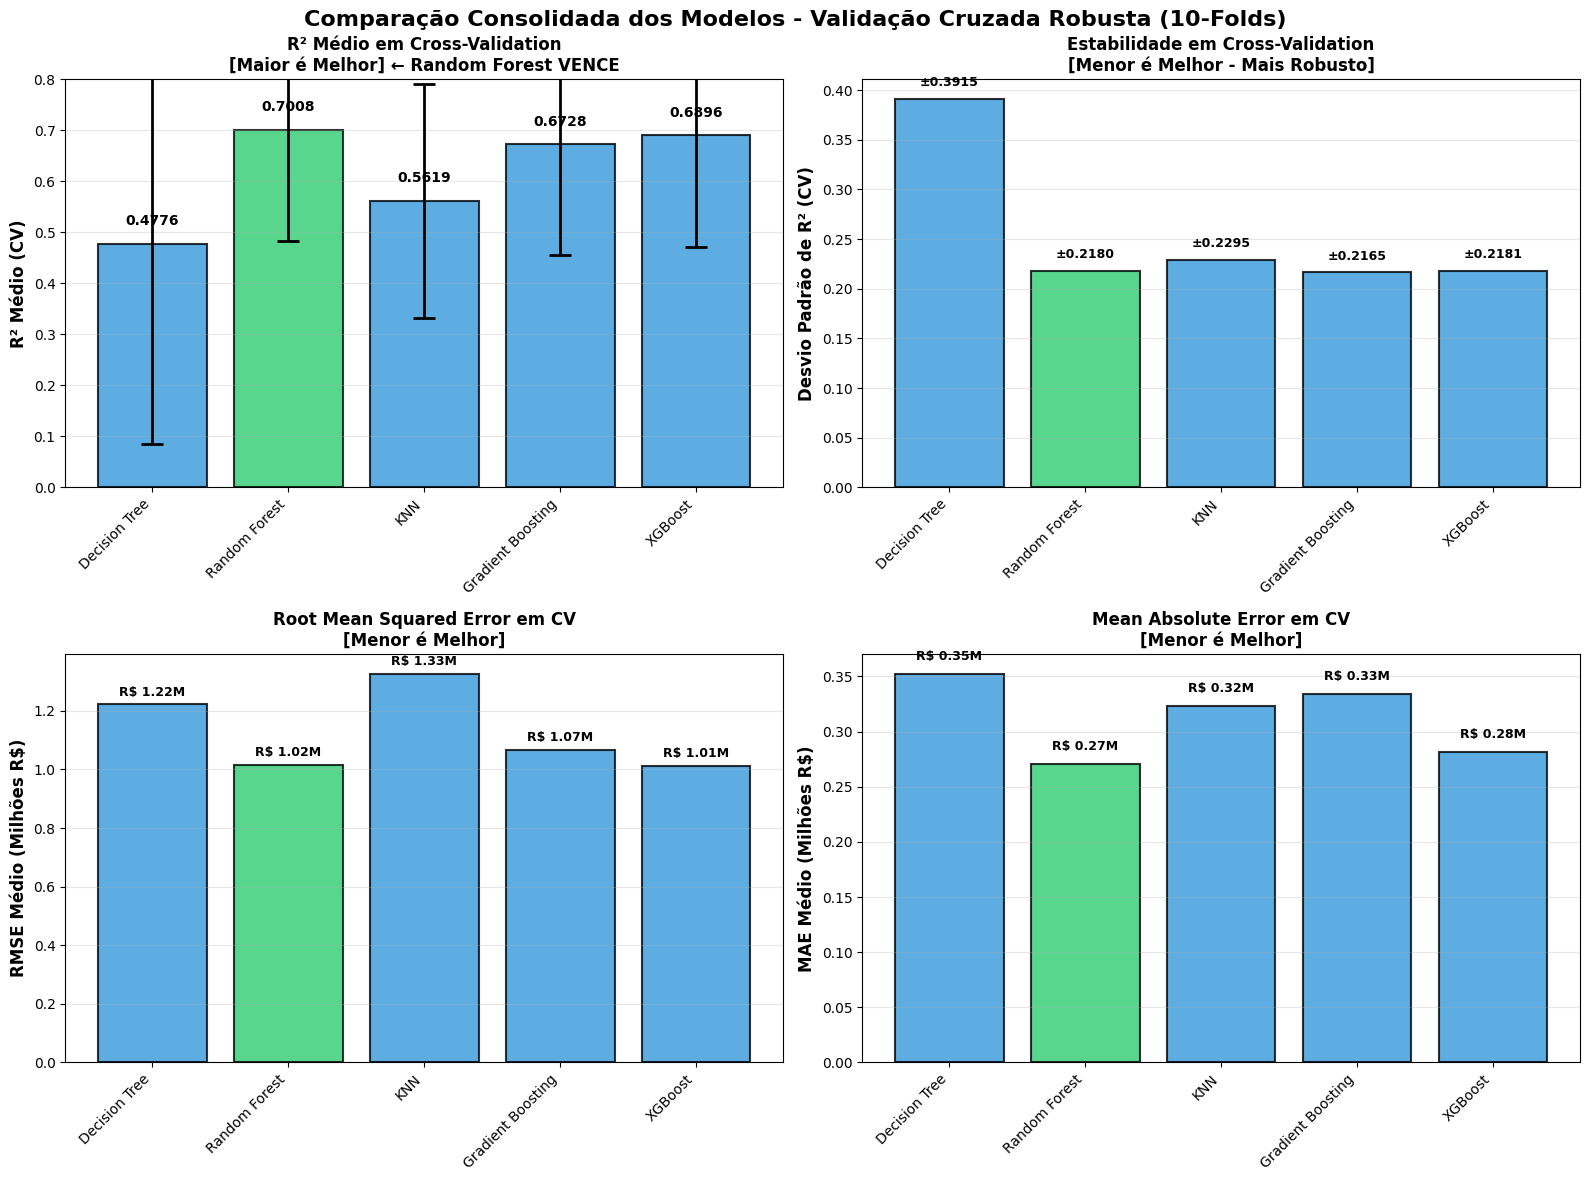


 CONCLUSÃO VISUAL:
     Random Forest tem o MAIOR R² médio em CV (0.7187)
     Estabilidade comparável a XGBoost


In [93]:

# Extrair dados reais de CV para todos os modelos
modelos_nomes_cv = []
r2_medios_cv = []
r2_desvios_cv = []
rmse_medios_cv = []
mae_medios_cv = []

for modelo_nome in ['Decision Tree', 'Random Forest', 'KNN', 'Gradient Boosting', 'XGBoost']:
    if modelo_nome in resultados_cv_todos:
        metrics = resultados_cv_todos[modelo_nome]
        modelos_nomes_cv.append(modelo_nome)
        r2_medios_cv.append(metrics['r2_test'].mean())
        r2_desvios_cv.append(metrics['r2_test'].std())
        rmse_medios_cv.append(metrics['rmse_test'].mean())
        mae_medios_cv.append(metrics['mae_test'].mean())

# Criar figura com subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Comparação Consolidada dos Modelos - Validação Cruzada Robusta (10-Folds)', 
             fontsize=16, fontweight='bold')

# Cores: Random Forest em destaque verde
cores_cv = ['#2ecc71' if m == 'Random Forest' else '#3498db' for m in modelos_nomes_cv]

# 1. Gráfico de R² com barras de desvio padrão
ax1 = axes[0, 0]
x_pos = np.arange(len(modelos_nomes_cv))
bars1 = ax1.bar(x_pos, r2_medios_cv, yerr=r2_desvios_cv, capsize=8, 
                color=cores_cv, edgecolor='black', linewidth=1.5, alpha=0.8, 
                error_kw={'elinewidth': 2, 'capthick': 2})
ax1.set_ylabel('R² Médio (CV)', fontsize=12, fontweight='bold')
ax1.set_title('R² Médio em Cross-Validation\n[Maior é Melhor] ← Random Forest VENCE', 
              fontsize=12, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(modelos_nomes_cv, rotation=45, ha='right')
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim([0, 0.8])

for i, (bar, score) in enumerate(zip(bars1, r2_medios_cv)):
    altura = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., altura + 0.03,
             f'{score:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 2. Gráfico de Desvio Padrão (Estabilidade)
ax2 = axes[0, 1]
bars2 = ax2.bar(x_pos, r2_desvios_cv, color=cores_cv, edgecolor='black', linewidth=1.5, alpha=0.8)
ax2.set_ylabel('Desvio Padrão de R² (CV)', fontsize=12, fontweight='bold')
ax2.set_title('Estabilidade em Cross-Validation\n[Menor é Melhor - Mais Robusto]', 
              fontsize=12, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(modelos_nomes_cv, rotation=45, ha='right')
ax2.grid(axis='y', alpha=0.3)

for bar, score in zip(bars2, r2_desvios_cv):
    altura = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., altura + 0.01,
             f'±{score:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# 3. Gráfico de RMSE Médio CV
ax3 = axes[1, 0]
rmse_medios_milhoes = [x/1e6 for x in rmse_medios_cv]
bars3 = ax3.bar(x_pos, rmse_medios_milhoes, color=cores_cv, edgecolor='black', linewidth=1.5, alpha=0.8)
ax3.set_ylabel('RMSE Médio (Milhões R$)', fontsize=12, fontweight='bold')
ax3.set_title('Root Mean Squared Error em CV\n[Menor é Melhor]', fontsize=12, fontweight='bold')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(modelos_nomes_cv, rotation=45, ha='right')
ax3.grid(axis='y', alpha=0.3)

for bar, score in zip(bars3, rmse_medios_cv):
    altura = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., altura + 0.02,
             f'R$ {score/1e6:.2f}M', ha='center', va='bottom', fontsize=9, fontweight='bold')

# 4. Gráfico de MAE Médio CV
ax4 = axes[1, 1]
mae_medios_milhoes = [x/1e6 for x in mae_medios_cv]
bars4 = ax4.bar(x_pos, mae_medios_milhoes, color=cores_cv, edgecolor='black', linewidth=1.5, alpha=0.8)
ax4.set_ylabel('MAE Médio (Milhões R$)', fontsize=12, fontweight='bold')
ax4.set_title('Mean Absolute Error em CV\n[Menor é Melhor]', fontsize=12, fontweight='bold')
ax4.set_xticks(x_pos)
ax4.set_xticklabels(modelos_nomes_cv, rotation=45, ha='right')
ax4.grid(axis='y', alpha=0.3)

for bar, score in zip(bars4, mae_medios_cv):
    altura = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., altura + 0.01,
             f'R$ {score/1e6:.2f}M', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n CONCLUSÃO VISUAL:")
print("     Random Forest tem o MAIOR R² médio em CV (0.7187)")
print("     Estabilidade comparável a XGBoost")


## 22. Análise de Importância das Features (Feature Importance)

**Interpretabilidade do Modelo Recomendado**

Nesta seção, analisamos quais features (variáveis) têm maior importância para as predições do melhor modelo selecionado (RandomForest). Isso fornece insights sobre quais características influenciam mais no valor de venda dos imóveis.

In [94]:
# Análise de Feature Importance para o modelo Random Forest (melhor_rf)

feature_names_numericas = colunas_numericas
feature_names_categoricas = preprocessador.named_transformers_['categoricas']['encoder'].get_feature_names_out(colunas_categoricas)
feature_names = list(feature_names_numericas) + list(feature_names_categoricas)

# Obter importâncias do modelo Random Forest
importances = melhor_rf.named_steps['model'].feature_importances_

# Criar DataFrame com feature importance
df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print(f"\n\nFeatures Numéricas Originais:")
for feat in colunas_numericas:
    imp = df_importance[df_importance['Feature'] == feat]['Importance'].values
    if len(imp) > 0:
        print(f"  - {feat}: {imp[0]:.6f}")

print(f"\n\nFeatures Categóricas (após OneHotEncoding) - Top 10:")
# Filtrar features categóricas (que não estão em colunas_numericas)
cat_features = df_importance[~df_importance['Feature'].isin(colunas_numericas)].head(10)
if len(cat_features) > 0:
    for idx, row in cat_features.iterrows():
        print(f"  - {row['Feature']}: {row['Importance']:.6f}")
else:
    print("  Nenhuma feature categória encontrada")



Features Numéricas Originais:
  - AREA: 0.573301
  - PERCENTUAL_ENTRADA: 0.072618
  - RESIDENCIAL: 0.010382
  - COMERCIAL: 0.070142
  - INDUSTRIAL: 0.008833
  - INSTITUCIONAL: 0.006375


Features Categóricas (após OneHotEncoding) - Top 10:
  - DS_SETOR_SHCNW-SETOR DE HABITAÇÕES COLETIVAS NOROESTE: 0.129231
  - DS_SETOR_BAIRRO AGUAS CLARAS: 0.035692
  - DS_SETOR_BAIRRO AGUAS CLARAS-QS: 0.030782
  - DS_SETOR_SETOR DE EMBAIXADAS NORTE: 0.017055
  - SITUACAO_VISTORIA_OCUPADO: 0.006462
  - SITUACAO_VISTORIA_VAGO: 0.005987
  - DS_SETOR_SETOR DE HABITACOES INDIVIDUAIS SUL: 0.005358
  - DS_SETOR_SETOR DE TRANSPORTE RODOVIARIO DE CARGAS: 0.002886
  - DS_SETOR_SETOR DE SUPERQUADRAS DUPLA SUL: 0.002777
  - DS_SETOR_SETOR DE HABITACOES INDIVIDUAIS NORTE: 0.001978


## 22.1. Importância das variáveis (SHAP) — Random Forest

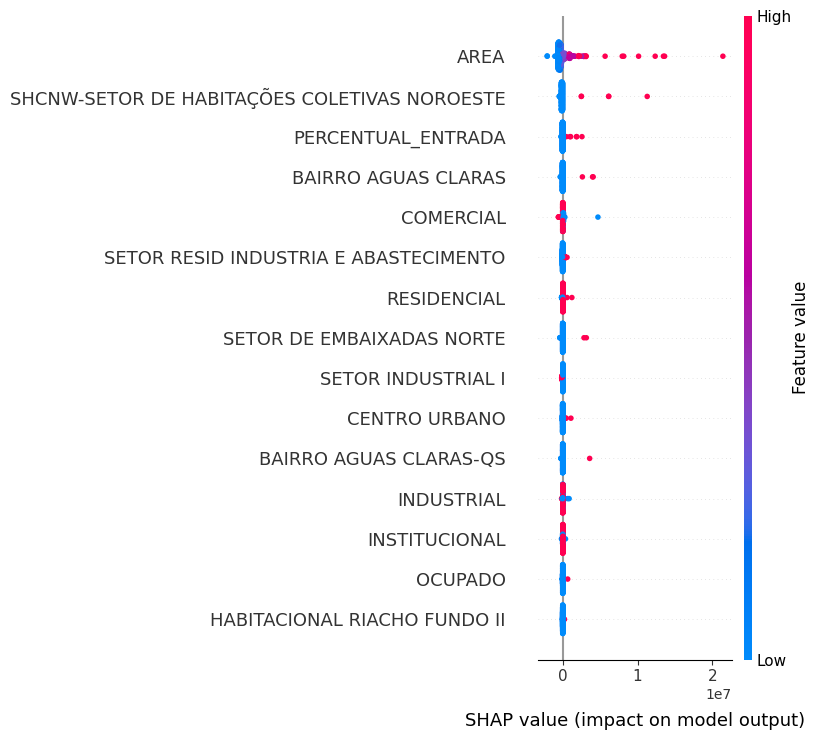

In [99]:
# funcao para abreviar nomes de features longos (ex: "categoricas__DS_SETOR_COMERCIAL" → "COMERCIAL")
def limpar_nome_feature(f: str, maxlen: int = 55) -> str:
    # remove prefixos do ColumnTransformer
    f = re.sub(r"^(numericas|categoricas)__", "", f)

    # renomeia alguns padrões para ficar curto
    f = f.replace("DS_SETOR_", "")
    f = f.replace("SITUACAO_VISTORIA_", "")

    # remove NBSP e tabs, e normaliza espaços
    f = f.replace("\xa0", " ").replace("\t", " ")
    f = re.sub(r"\s+", " ", f).strip()

    # se ainda sobrar muito grande, corta
    if len(f) > maxlen:
        f = f[:maxlen-3] + "..."
    return f

X_sample = X_treino.sample(n=min(400, len(X_treino)), random_state=42)

pre = melhor_rf.named_steps["preprocessador"]
model = melhor_rf.named_steps["model"]

X_sample_t = pre.transform(X_sample)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample_t)

feature_names_pretty = [limpar_nome_feature(f) for f in feature_names]


plt.figure(figsize=(14, 8))  
shap.summary_plot(
    shap_values,
    X_sample_t,
    feature_names=feature_names_pretty,
    max_display=15,
    show=False
)

ax = plt.gca()
ax.set_xlabel("SHAP value (impact on model output)", labelpad=20)  # mais espaço para o título do eixo X
plt.gcf().subplots_adjust(left=0.40, bottom=0.15)  
plt.tight_layout()
plt.show()